This page is deciated to visualize the distribution of $\hat R_{\nu}$ for various distributions. The proposed distribution of $\hat R_{\nu}$ requires that the subchain being greater than 1. So the plot is unable to show distribution of $\hat R_{\nu}$ with naive initialization.

In [ ]:
import numpy as np
from google.colab import drive
from matplotlib.lines import Line2D
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


**Necessary Parameter Setup**

In [ ]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [ ]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

In [ ]:
# utility_link = '/content/drive/MyDrive/JHU Stuff/Capstone/Utility_Functions/Dimension_Utility.py'
# with open(utility_link) as f: exec(f.read())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f


def plot_rhat_histograms_with_pdf(
    df,
    distribution_name,
    K,
    M,
    warmups,
    bins=30
):
    """
    Plot empirical Rhat density histograms and theoretical Rhat PDFs
    for 9 specified Warmup Lengths.

    Each subplot has its own independent x-axis and y-axis range.

    The theoretical distribution is:

        Rhat = sqrt(1 + F/M)

    where:

        F ~ F(K-1, K(M-1))

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing at least:
        "Rhat" and "Warmup Length"

    distribution_name : str
        Name of the target distribution.

    K : int
        Number of subchains.

    M : int
        Number of chains per subchain.

    warmups : list
        List containing exactly 9 Warmup Length values.

    bins : int
        Number of histogram bins.
    """

    # --------------------------------------------------
    # Check that exactly 9 warmup lengths were provided
    # --------------------------------------------------
    if len(warmups) != 9:
        raise ValueError(
            "warmups must contain exactly 9 Warmup Length values."
        )

    # --------------------------------------------------
    # F distribution degrees of freedom
    # --------------------------------------------------
    df_num = K - 1
    df_den = K * (M - 1)

    # --------------------------------------------------
    # Theoretical Rhat PDF
    #
    # Rhat = sqrt(1 + F/M)
    #
    # F = M * (Rhat^2 - 1)
    #
    # Jacobian = 2 * M * Rhat
    # --------------------------------------------------
    def rhat_pdf(r):

        r = np.asarray(r, dtype=float)

        f_value = M * (r**2 - 1)

        pdf = np.zeros_like(
            r,
            dtype=float
        )

        valid = r >= 1

        pdf[valid] = (
            f.pdf(
                f_value[valid],
                df_num,
                df_den
            )
            * 2 * M * r[valid]
        )

        return pdf

    # --------------------------------------------------
    # Calculate theoretical percentiles
    # --------------------------------------------------
    f_q05 = f.ppf(
        0.05,
        df_num,
        df_den
    )

    f_q95 = f.ppf(
        0.95,
        df_num,
        df_den
    )

    rhat_q05 = np.sqrt(
        1 + f_q05 / M
    )

    rhat_q95 = np.sqrt(
        1 + f_q95 / M
    )

    # --------------------------------------------------
    # Calculate theoretical 99.9th percentile
    # Used to determine PDF plotting range
    # --------------------------------------------------
    f_q999 = f.ppf(
        0.999,
        df_num,
        df_den
    )

    rhat_q999 = np.sqrt(
        1 + f_q999 / M
    )

    # --------------------------------------------------
    # Create 3 x 3 subplot grid
    #
    # sharex=False and sharey=False ensure each plot
    # determines its own axis limits.
    # --------------------------------------------------
    fig, axes = plt.subplots(
        3,
        3,
        figsize=(18, 14),
        dpi=150,
        sharex=False,
        sharey=False
    )

    axes = axes.flatten()

    # --------------------------------------------------
    # Plot each Warmup Length
    # --------------------------------------------------
    for ax, warmup in zip(axes, warmups):

        # ----------------------------------------------
        # Select Rhat values for current Warmup Length
        # ----------------------------------------------
        rhat_data = df.loc[
            df["Warmup Length"] == warmup,
            "Rhat"
        ].dropna()

        # ----------------------------------------------
        # Convert JAX objects to NumPy floats
        #
        # Does NOT modify original DataFrame.
        # ----------------------------------------------
        rhat_values = np.asarray(
            [
                float(x)
                for x in rhat_data
            ],
            dtype=float
        )

        # ----------------------------------------------
        # Check data exists
        # ----------------------------------------------
        if len(rhat_values) == 0:

            ax.set_title(
                f"Warmup Length = {warmup}"
            )

            ax.text(
                0.5,
                0.5,
                "No data",
                horizontalalignment="center",
                verticalalignment="center",
                transform=ax.transAxes
            )

            continue

        # ----------------------------------------------
        # Determine individual x-axis range
        #
        # Each subplot uses its own empirical maximum.
        # ----------------------------------------------
        x_min = 1.0

        x_max = max(
            rhat_values.max(),
            rhat_q999
        )

        # Add 2% padding
        x_max = x_max + 0.02 * (
            x_max - x_min
        )

        # ----------------------------------------------
        # Generate PDF for this subplot
        #
        # Same theoretical distribution, but evaluated
        # over the subplot's own x-range.
        # ----------------------------------------------
        x = np.linspace(
            x_min,
            x_max,
            2000
        )

        y = rhat_pdf(x)

        # ----------------------------------------------
        # Empirical histogram
        # ----------------------------------------------
        ax.hist(
            rhat_values,
            bins=bins,
            density=True,
            alpha=0.6,
            edgecolor="black",
            label="Empirical Rhat"
        )

        # ----------------------------------------------
        # Theoretical PDF
        # ----------------------------------------------
        ax.plot(
            x,
            y,
            linewidth=2.5,
            label="Theoretical PDF"
        )

        # ----------------------------------------------
        # 5th percentile
        # ----------------------------------------------
        ax.axvline(
            rhat_q05,
            linestyle="--",
            linewidth=1.5,
            label=f"5th = {rhat_q05:.3f}"
        )

        # ----------------------------------------------
        # 95th percentile
        # ----------------------------------------------
        ax.axvline(
            rhat_q95,
            linestyle="--",
            linewidth=1.5,
            label=f"95th = {rhat_q95:.3f}"
        )

        # ----------------------------------------------
        # Labels
        # ----------------------------------------------
        ax.set_xlabel("Rhat")
        ax.set_ylabel("Density")

        ax.set_title(
            f"Warmup Length = {warmup}"
        )

        ax.grid(alpha=0.3)

    # --------------------------------------------------
    # Overall title
    # --------------------------------------------------
    fig.suptitle(
        f"Empirical and Theoretical Rhat Distributions\n"
        f"Target Distribution: {distribution_name}",
        fontsize=18
    )

    # --------------------------------------------------
    # Add one shared legend
    #
    # Use handles from first subplot.
    # --------------------------------------------------
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.93),
        ncol=4
    )

    # --------------------------------------------------
    # Adjust layout
    # --------------------------------------------------
    plt.tight_layout(
        rect=[0, 0, 1, 0.88]
    )

    plt.show()

In [ ]:
warmup_lengths = [
    10, 20, 30,
    40, 50, 100,
    200, 500, 1000
]

## **Paper Distributions**

In [ ]:
##########################
# BlackJAX implementation:
##########################
# MSE vs nested Rhat:
Iso_R_hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/DimensionExperiment/Iso_Rhat_c.pkl"
Iso_R_Hat_c_df = pd.read_pickle(Iso_R_hat_c_path)

Iso_R_hat_n_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/DimensionExperiment/Iso_Rhat_n.pkl"
Iso_R_Hat_n_df = pd.read_pickle(Iso_R_hat_n_path)
print("Isotropic covariance data Loaded!")

Isotropic covariance data Loaded!


For Constrained Initialization, the set of histograms are the following:

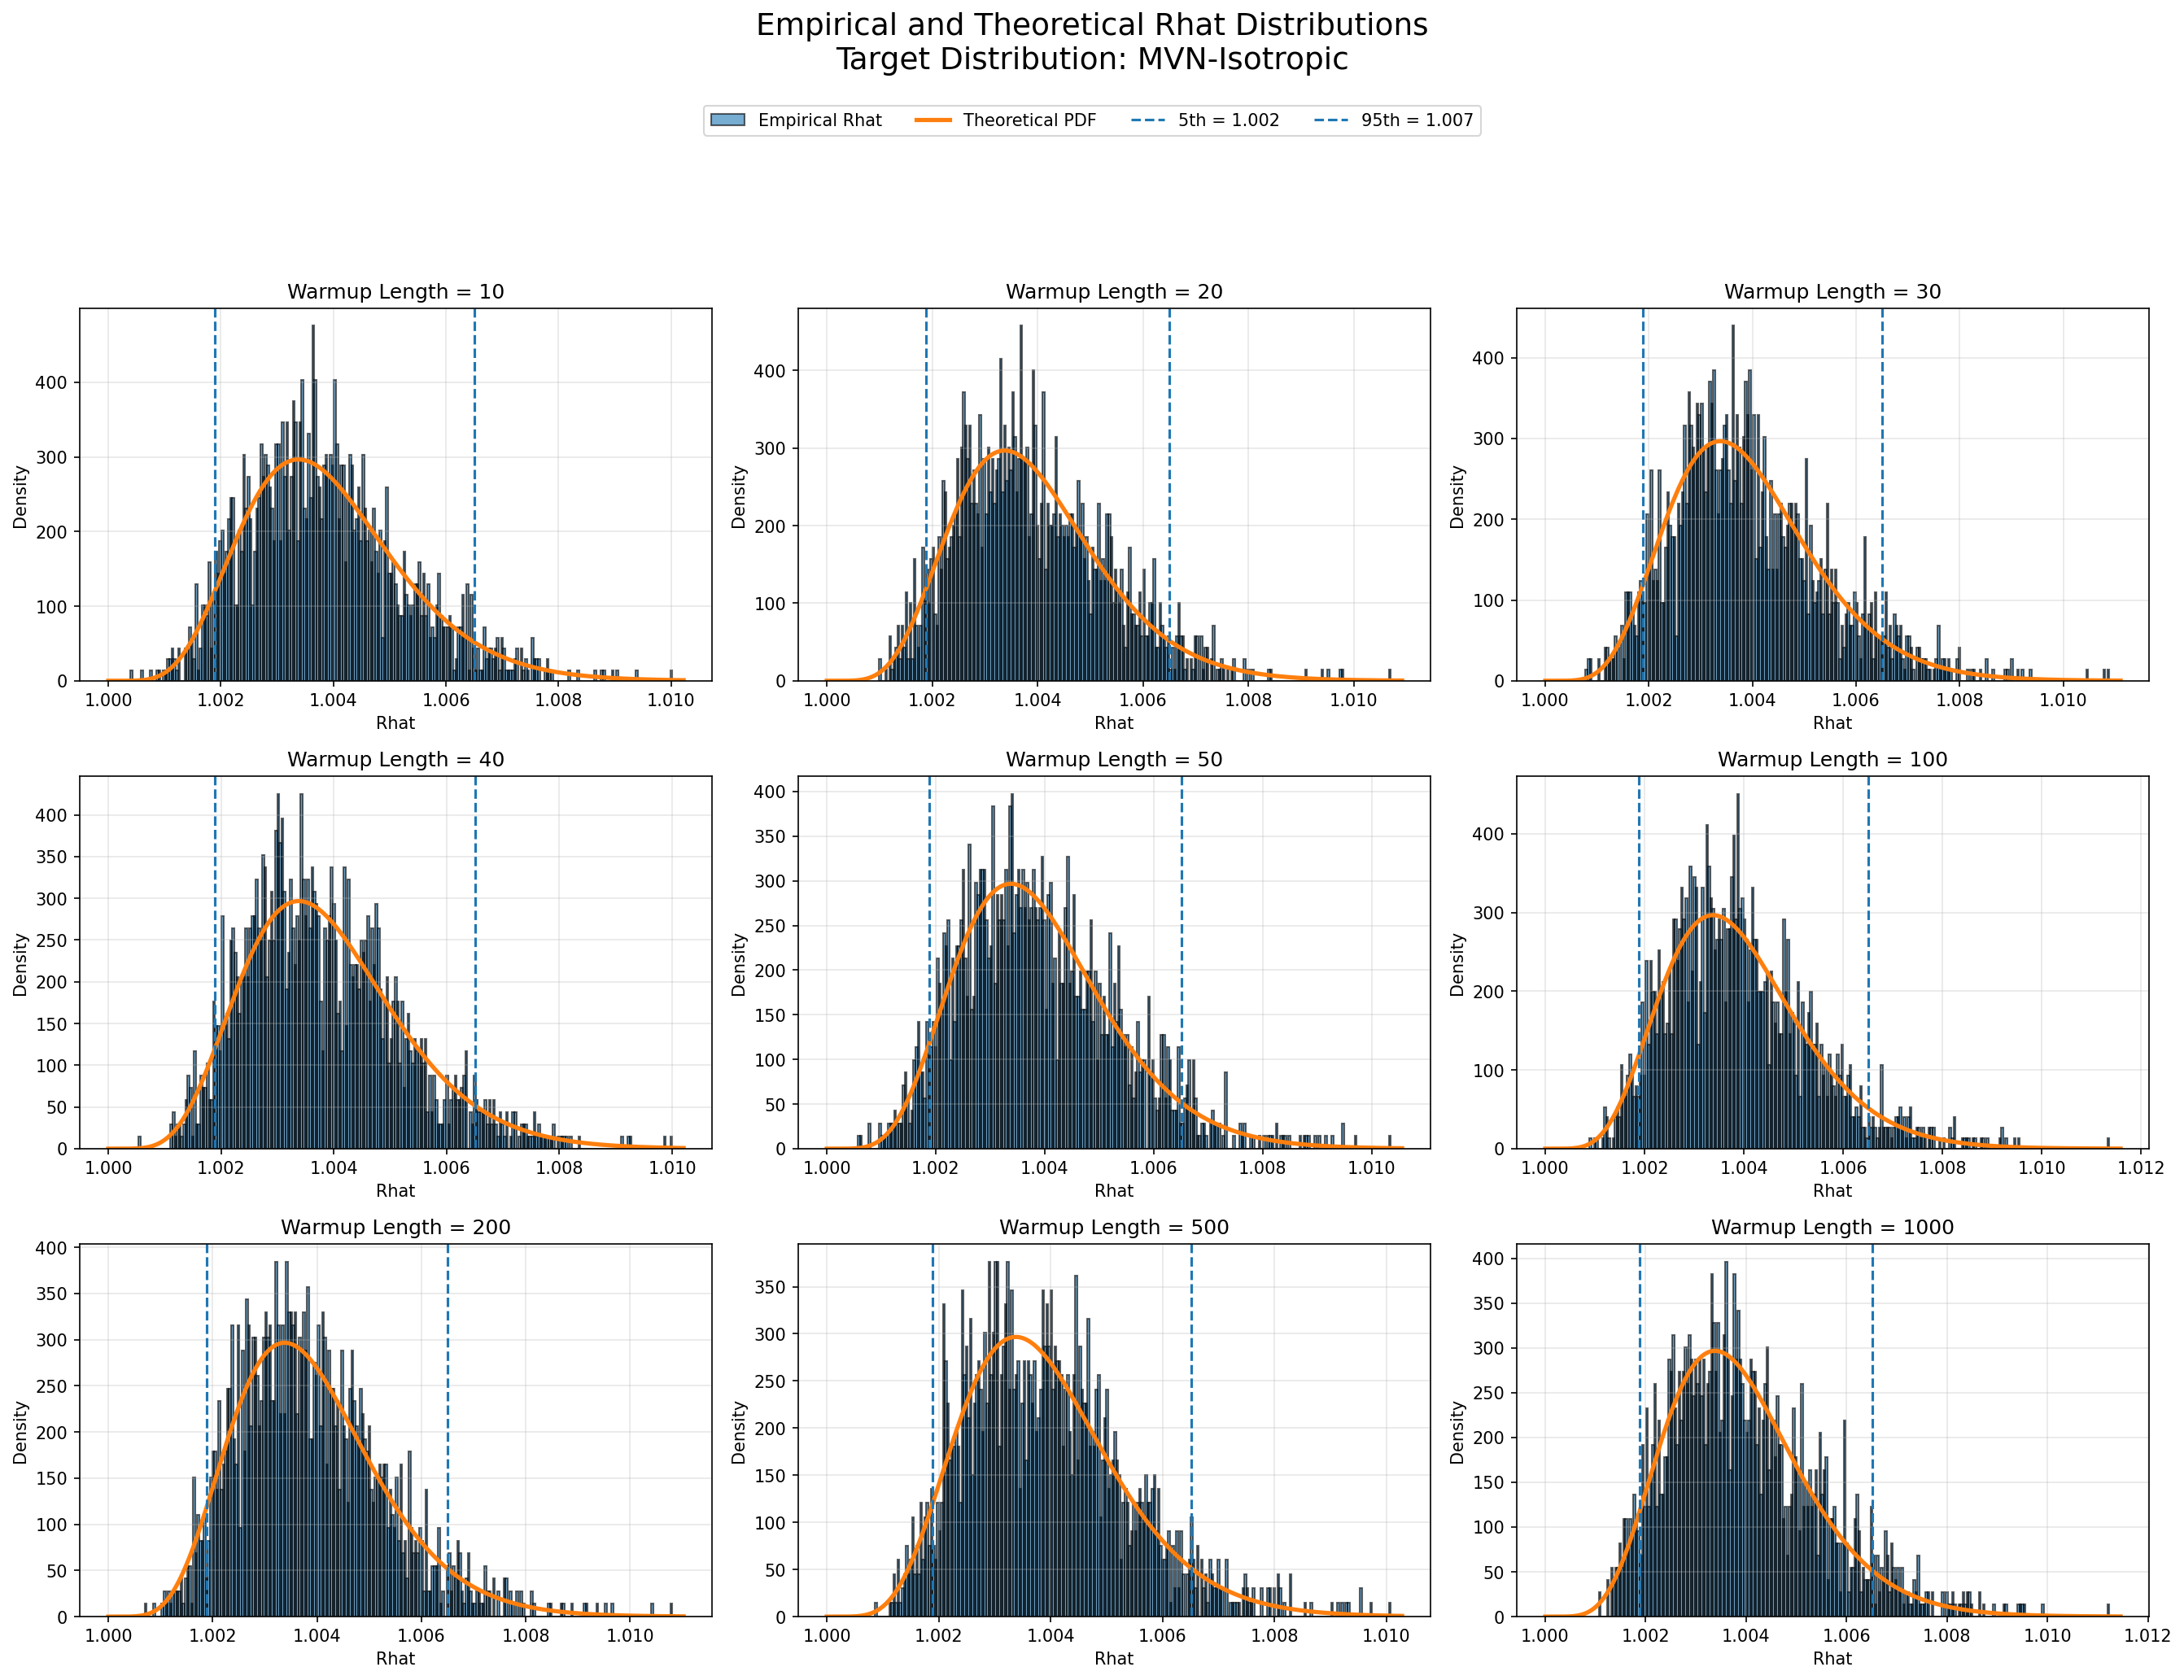

In [ ]:
warmup_lengths = [
    10, 20, 30,
    40, 50, 100,
    200, 500, 1000
]

plot_rhat_histograms_with_pdf(
    Iso_R_Hat_c_df,
    "MVN-Isotropic",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins=250
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f


def plot_rhat_histogram_with_pdf(
    df,
    distribution_name,
    K,
    M,
    warmup,
    bins=30
):
    """
    Plot the empirical Rhat density histogram and theoretical Rhat PDF
    for one specified Warmup Length.

    The theoretical distribution is:

        Rhat = sqrt(1 + F/M)

    where:

        F ~ F(K-1, K(M-1))

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing at least:
        "Rhat" and "Warmup Length"

    distribution_name : str
        Name of the target distribution.

    K : int
        Number of subchains.

    M : int
        Number of chains per subchain.

    warmup : int or float
        The Warmup Length to plot.

    bins : int
        Number of histogram bins.
    """

    # --------------------------------------------------
    # F distribution degrees of freedom
    # --------------------------------------------------
    df_num = K - 1
    df_den = K * (M - 1)

    # --------------------------------------------------
    # Select Rhat values for specified Warmup Length
    # --------------------------------------------------
    rhat_data = df.loc[
        df["Warmup Length"] == warmup,
        "Rhat"
    ].dropna()

    # --------------------------------------------------
    # Convert JAX objects to NumPy floats
    #
    # Does NOT modify the original DataFrame.
    # --------------------------------------------------
    rhat_values = np.asarray(
        [
            float(x)
            for x in rhat_data
        ],
        dtype=float
    )

    # --------------------------------------------------
    # Check data exists
    # --------------------------------------------------
    if len(rhat_values) == 0:
        raise ValueError(
            f"No Rhat values found for Warmup Length = {warmup}"
        )

    # --------------------------------------------------
    # Theoretical Rhat PDF
    #
    # Rhat = sqrt(1 + F/M)
    #
    # F = M * (Rhat^2 - 1)
    #
    # Jacobian = 2 * M * Rhat
    # --------------------------------------------------
    def rhat_pdf(r):

        r = np.asarray(r, dtype=float)

        f_value = M * (r**2 - 1)

        pdf = np.zeros_like(
            r,
            dtype=float
        )

        valid = r >= 1

        pdf[valid] = (
            f.pdf(
                f_value[valid],
                df_num,
                df_den
            )
            * 2 * M * r[valid]
        )

        return pdf

    # --------------------------------------------------
    # Calculate theoretical percentiles
    # --------------------------------------------------
    f_q05 = f.ppf(
        0.05,
        df_num,
        df_den
    )

    f_q95 = f.ppf(
        0.95,
        df_num,
        df_den
    )

    rhat_q05 = np.sqrt(
        1 + f_q05 / M
    )

    rhat_q95 = np.sqrt(
        1 + f_q95 / M
    )

    # --------------------------------------------------
    # Determine x-axis range
    #
    # Include empirical values and theoretical
    # 99.9th percentile.
    # --------------------------------------------------
    f_q999 = f.ppf(
        0.999,
        df_num,
        df_den
    )

    rhat_q999 = np.sqrt(
        1 + f_q999 / M
    )

    x_min = 1.0

    x_max = max(
        rhat_values.max(),
        rhat_q999
    )

    # Add small padding
    x_max = x_max + 0.02 * (
        x_max - x_min
    )

    # --------------------------------------------------
    # Generate theoretical PDF
    # --------------------------------------------------
    x = np.linspace(
        x_min,
        x_max,
        2000
    )

    y = rhat_pdf(x)

    # --------------------------------------------------
    # Create plot
    # --------------------------------------------------
    plt.figure(
        figsize=(10, 6),
        dpi=150
    )

    # --------------------------------------------------
    # Empirical histogram
    # --------------------------------------------------
    plt.hist(
        rhat_values,
        bins=bins,
        density=True,
        alpha=0.6,
        edgecolor="black",
        label="Empirical Rhat"
    )

    # --------------------------------------------------
    # Theoretical PDF
    # --------------------------------------------------
    plt.plot(
        x,
        y,
        linewidth=2.5,
        label="Theoretical PDF"
    )

    # --------------------------------------------------
    # 5th percentile
    # --------------------------------------------------
    plt.axvline(
        rhat_q05,
        linestyle="--",
        linewidth=2,
        label=f"5th percentile = {rhat_q05:.4f}"
    )

    # --------------------------------------------------
    # 95th percentile
    # --------------------------------------------------
    plt.axvline(
        rhat_q95,
        linestyle="--",
        linewidth=2,
        label=f"95th percentile = {rhat_q95:.4f}"
    )

    # --------------------------------------------------
    # Labels and title
    # --------------------------------------------------
    plt.xlabel("Rhat")
    plt.ylabel("Density")

    plt.title(
        f"Empirical and Theoretical Rhat Distribution\n"
        f"Target Distribution: {distribution_name} | "
        f"Warmup Length = {warmup}"
    )

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()

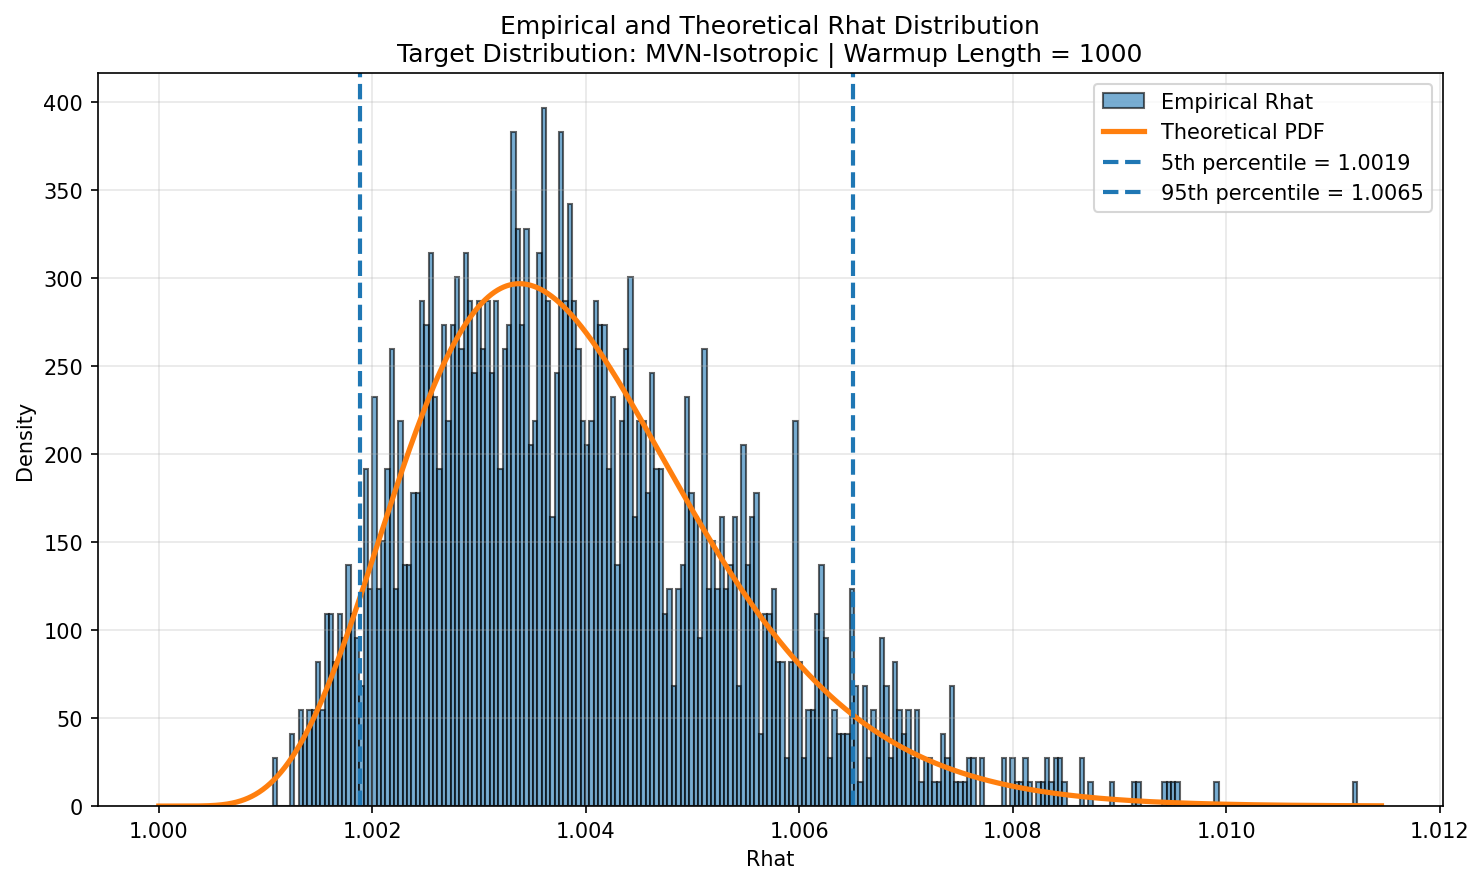

In [ ]:
plot_rhat_histogram_with_pdf(
    df=Iso_R_Hat_c_df,
    distribution_name="MVN-Isotropic",
    K=num_super_chains,
    M=num_chains_short // num_super_chains,
    warmup=1000,
    bins=250
)

In [ ]:
# MSE vs nested Rhat:
bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/IRT_R_Hat_constrained.pkl"
bjx_R_Hat_c_df = pd.read_pickle(bjx_R_hat_c_path)
print("BlackJAX implementation data Loaded!")

BlackJAX implementation data Loaded!


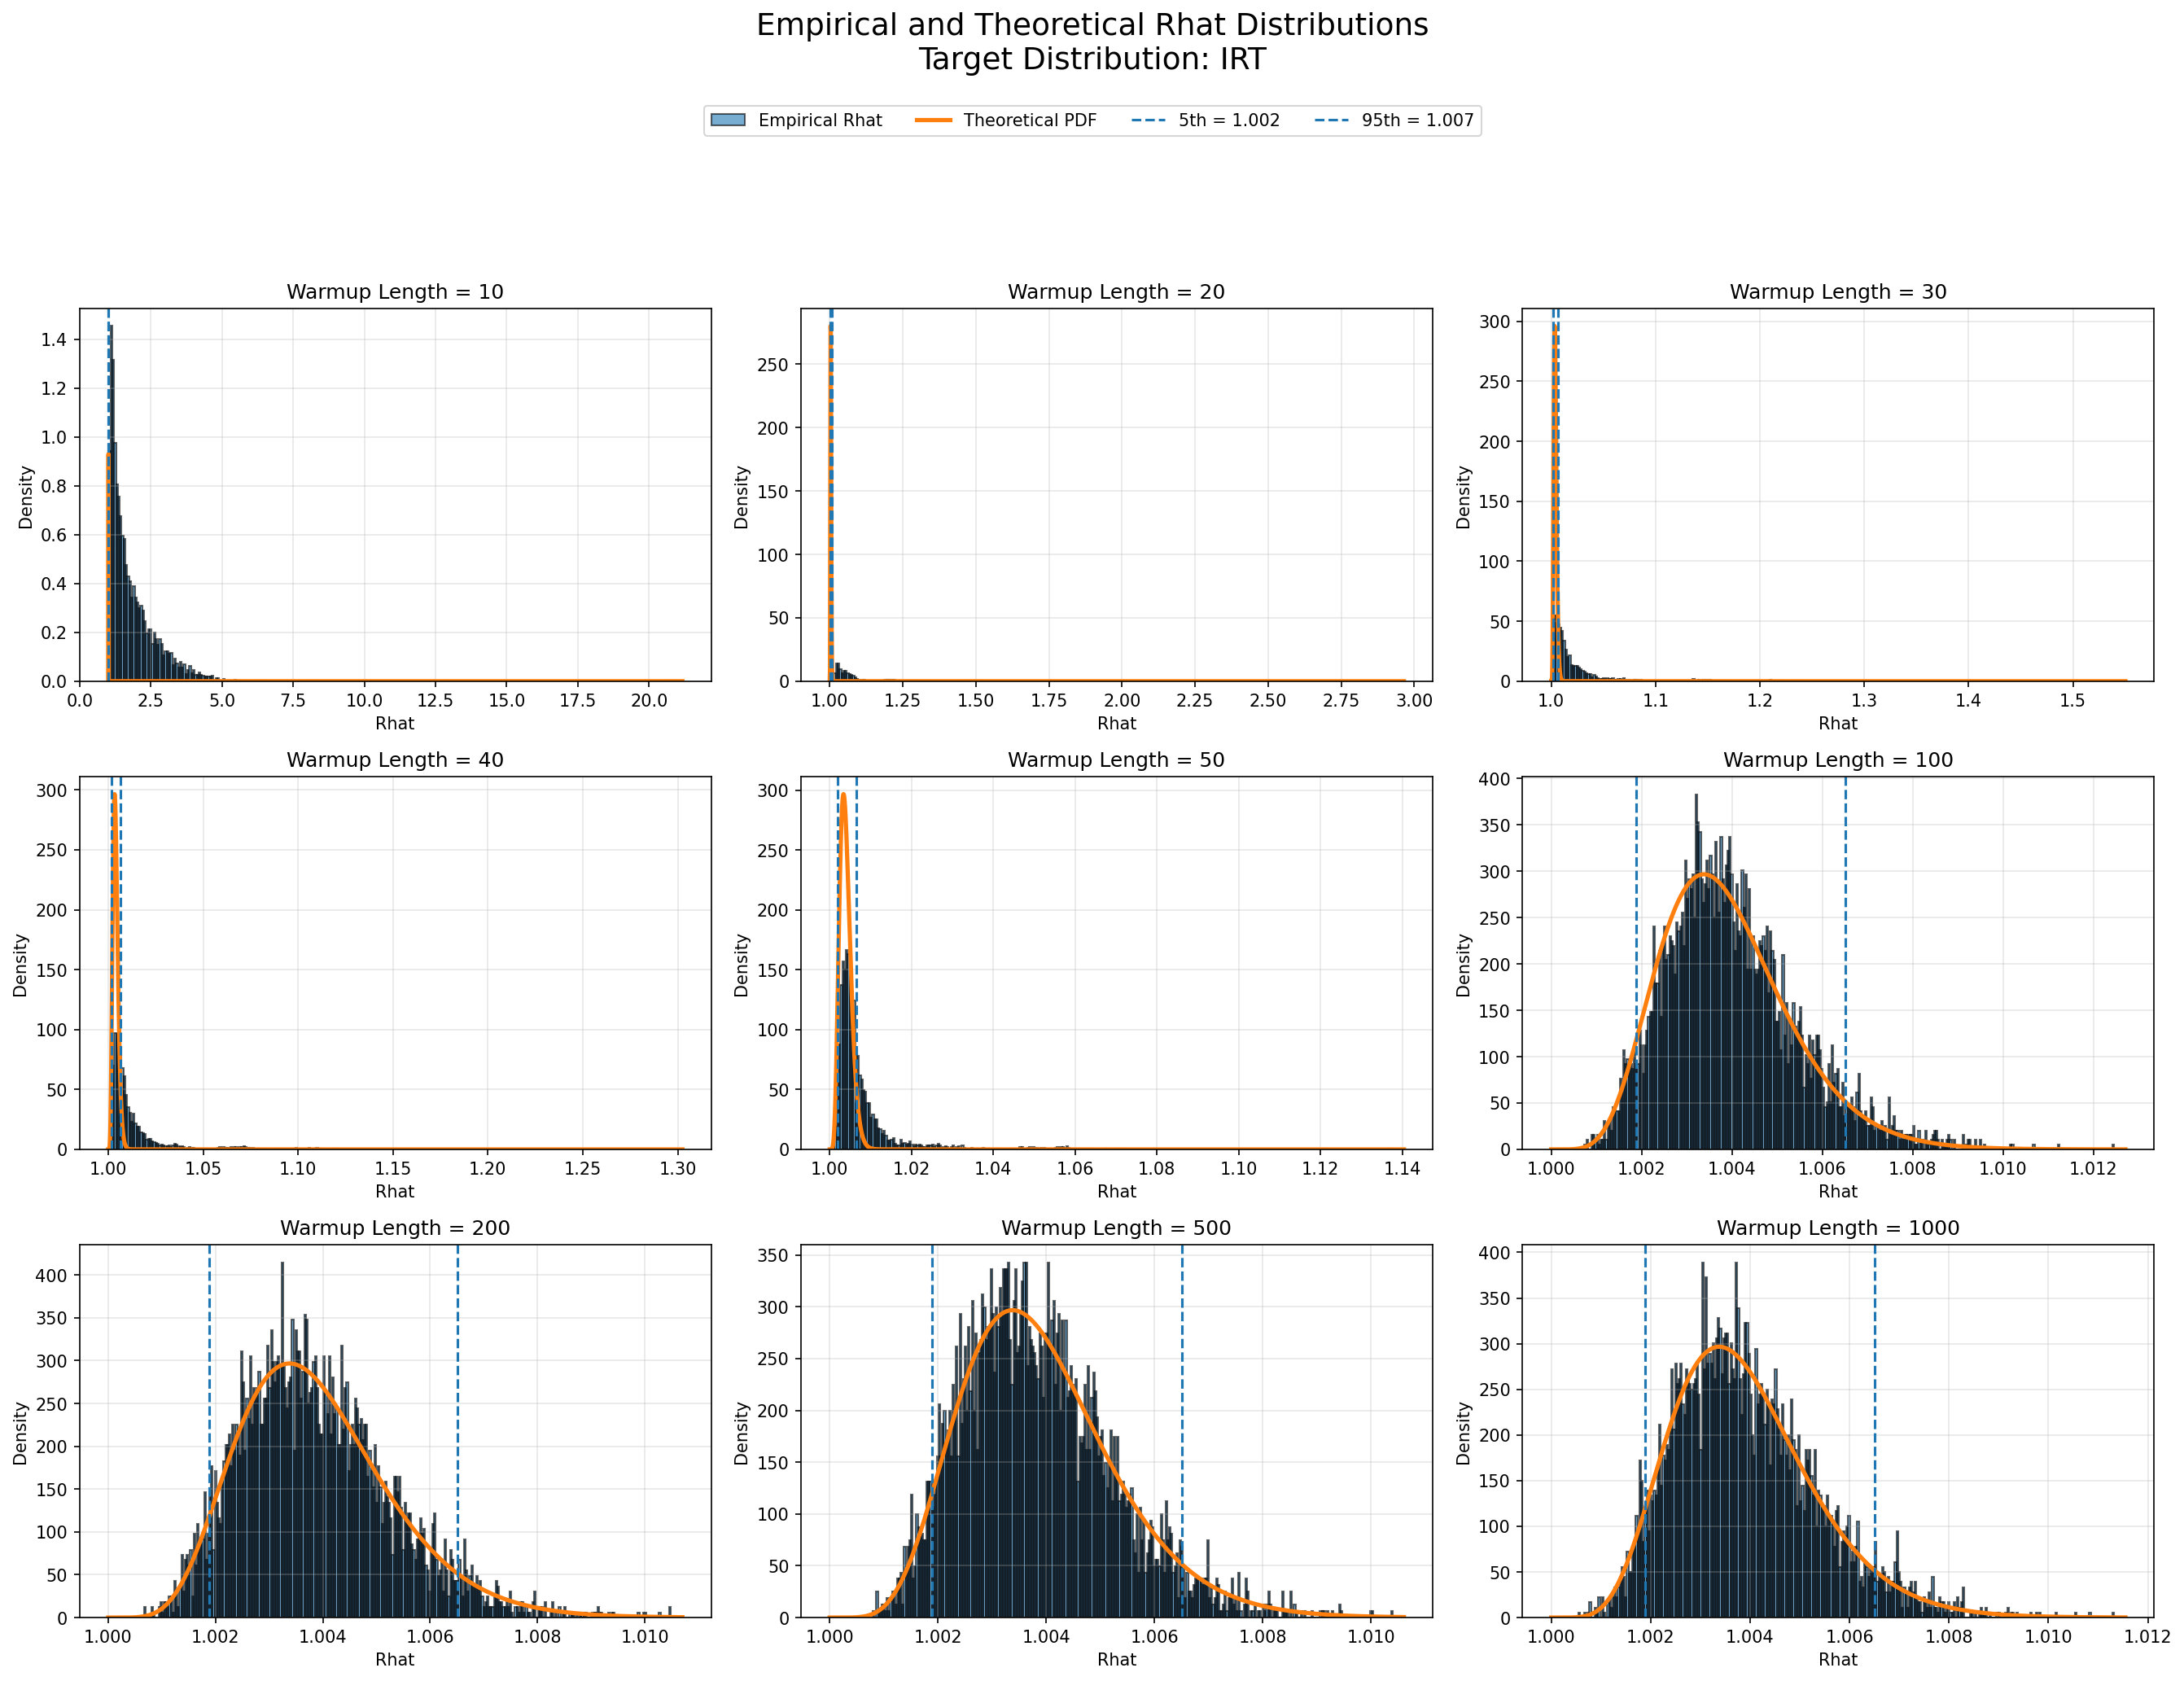

In [ ]:
plot_rhat_histograms_with_pdf(
    bjx_R_Hat_c_df,
    "IRT",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins=300
)

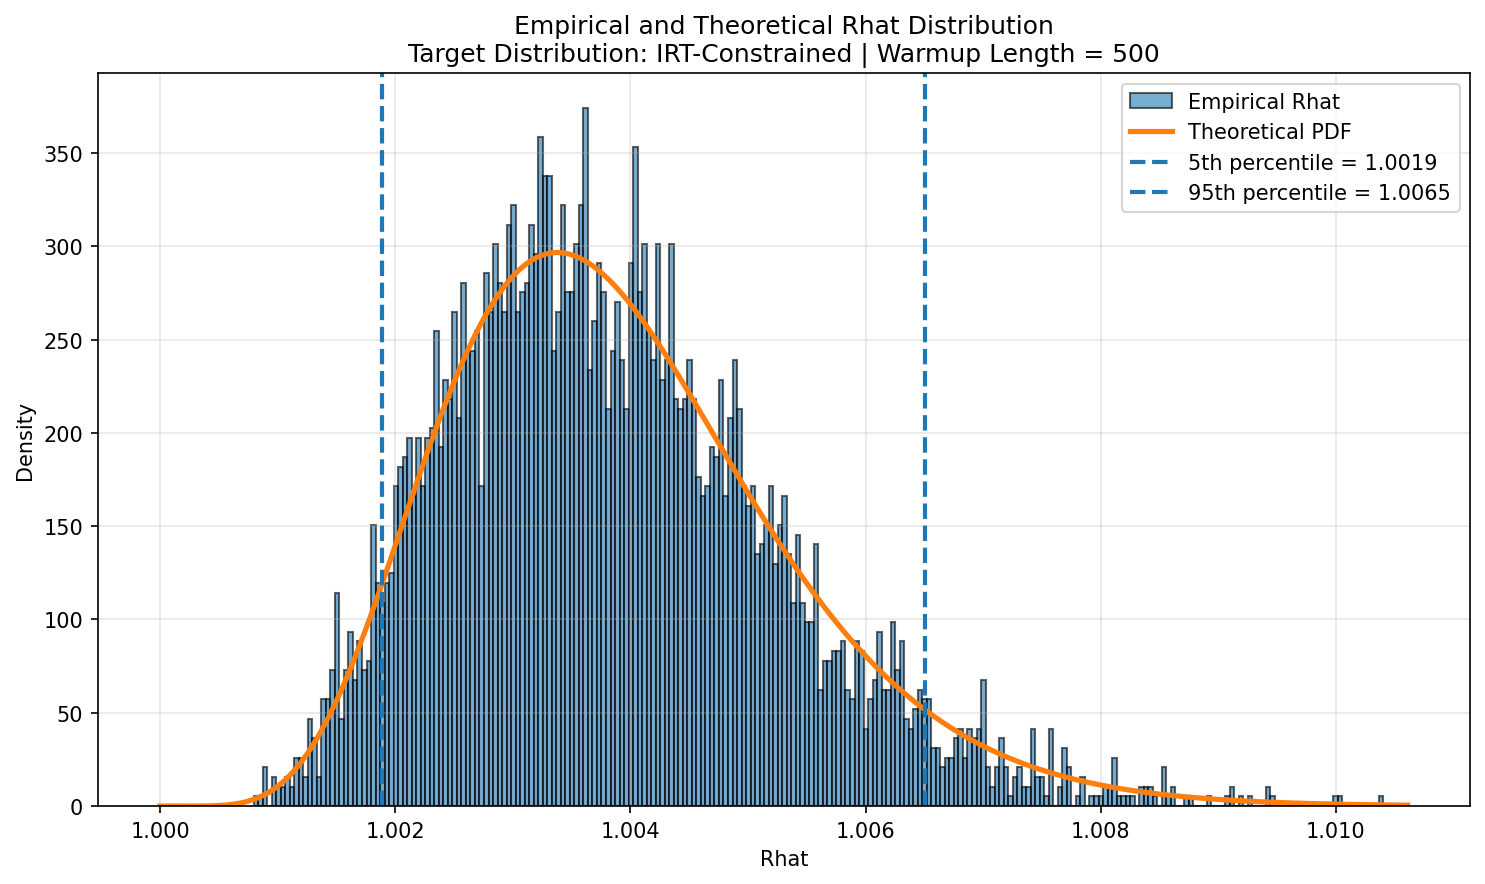

In [ ]:
plot_rhat_histogram_with_pdf(
    df=bjx_R_Hat_c_df,
    distribution_name="IRT-Constrained",
    K=num_super_chains,
    M=num_chains_short // num_super_chains,
    warmup=500,
    bins=250
)

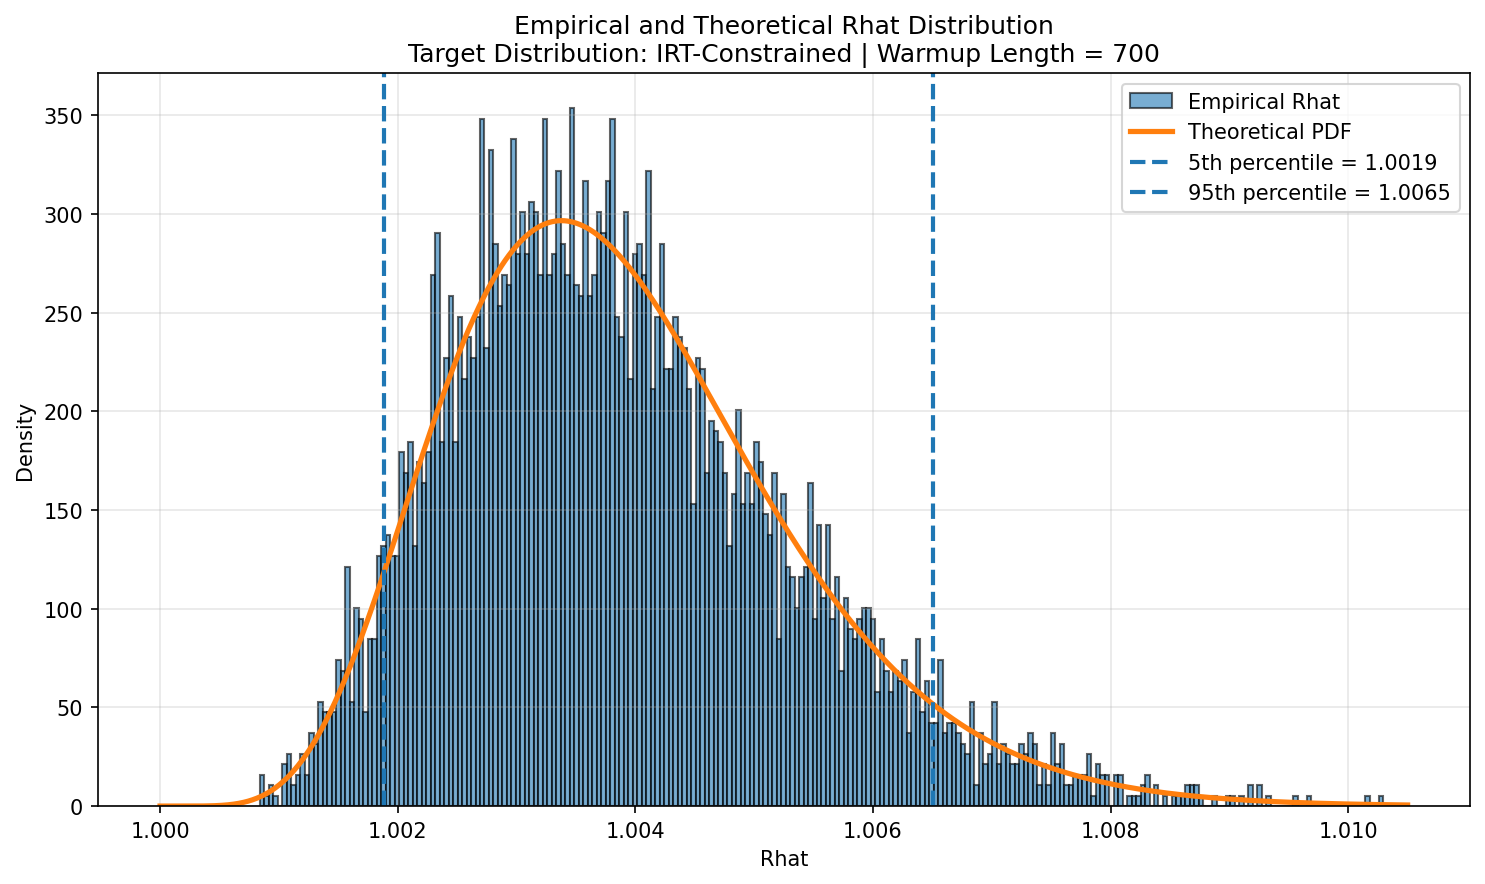

In [ ]:
plot_rhat_histogram_with_pdf(
    df=bjx_R_Hat_c_df,
    distribution_name="IRT-Constrained",
    K=num_super_chains,
    M=num_chains_short // num_super_chains,
    warmup=700,
    bins=250
)

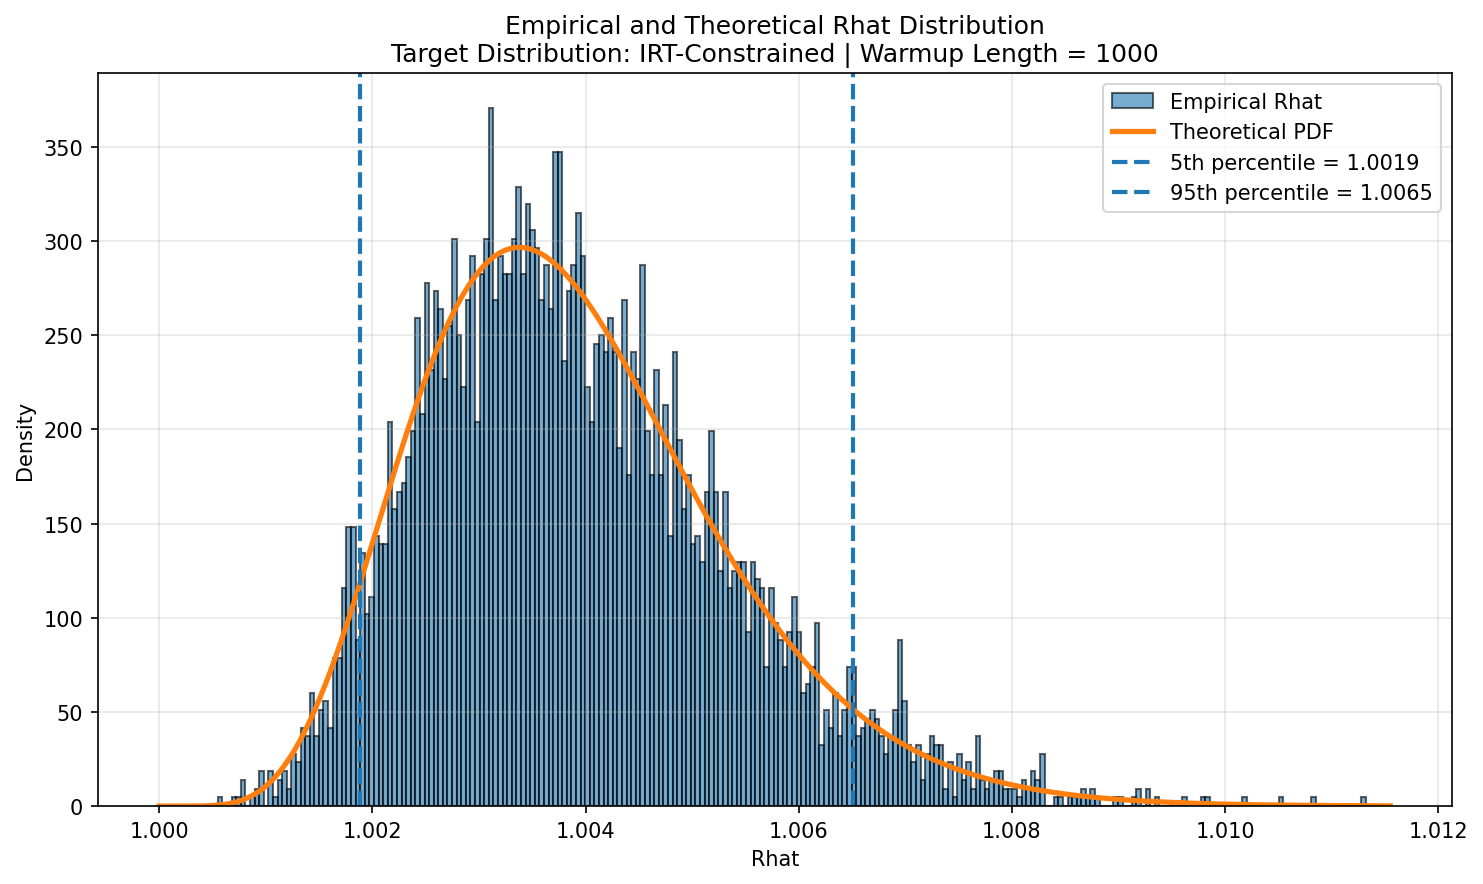

In [ ]:
plot_rhat_histogram_with_pdf(
    df=bjx_R_Hat_c_df,
    distribution_name="IRT-Constrained",
    K=num_super_chains,
    M=num_chains_short // num_super_chains,
    warmup=1000,
    bins=250
)

In [ ]:
# Eight School Distritbution:
# MSE vs nested Rhat:
pf_R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/InitializationExperiment/School_R_Hat.pkl"
pf_R_Hat_c_df = pd.read_pickle(pf_R_Hat_c_path)

In [ ]:
bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_R_Hat_constrained.pkl"
bjx_R_Hat_c_df = pd.read_pickle(bjx_R_hat_c_path)

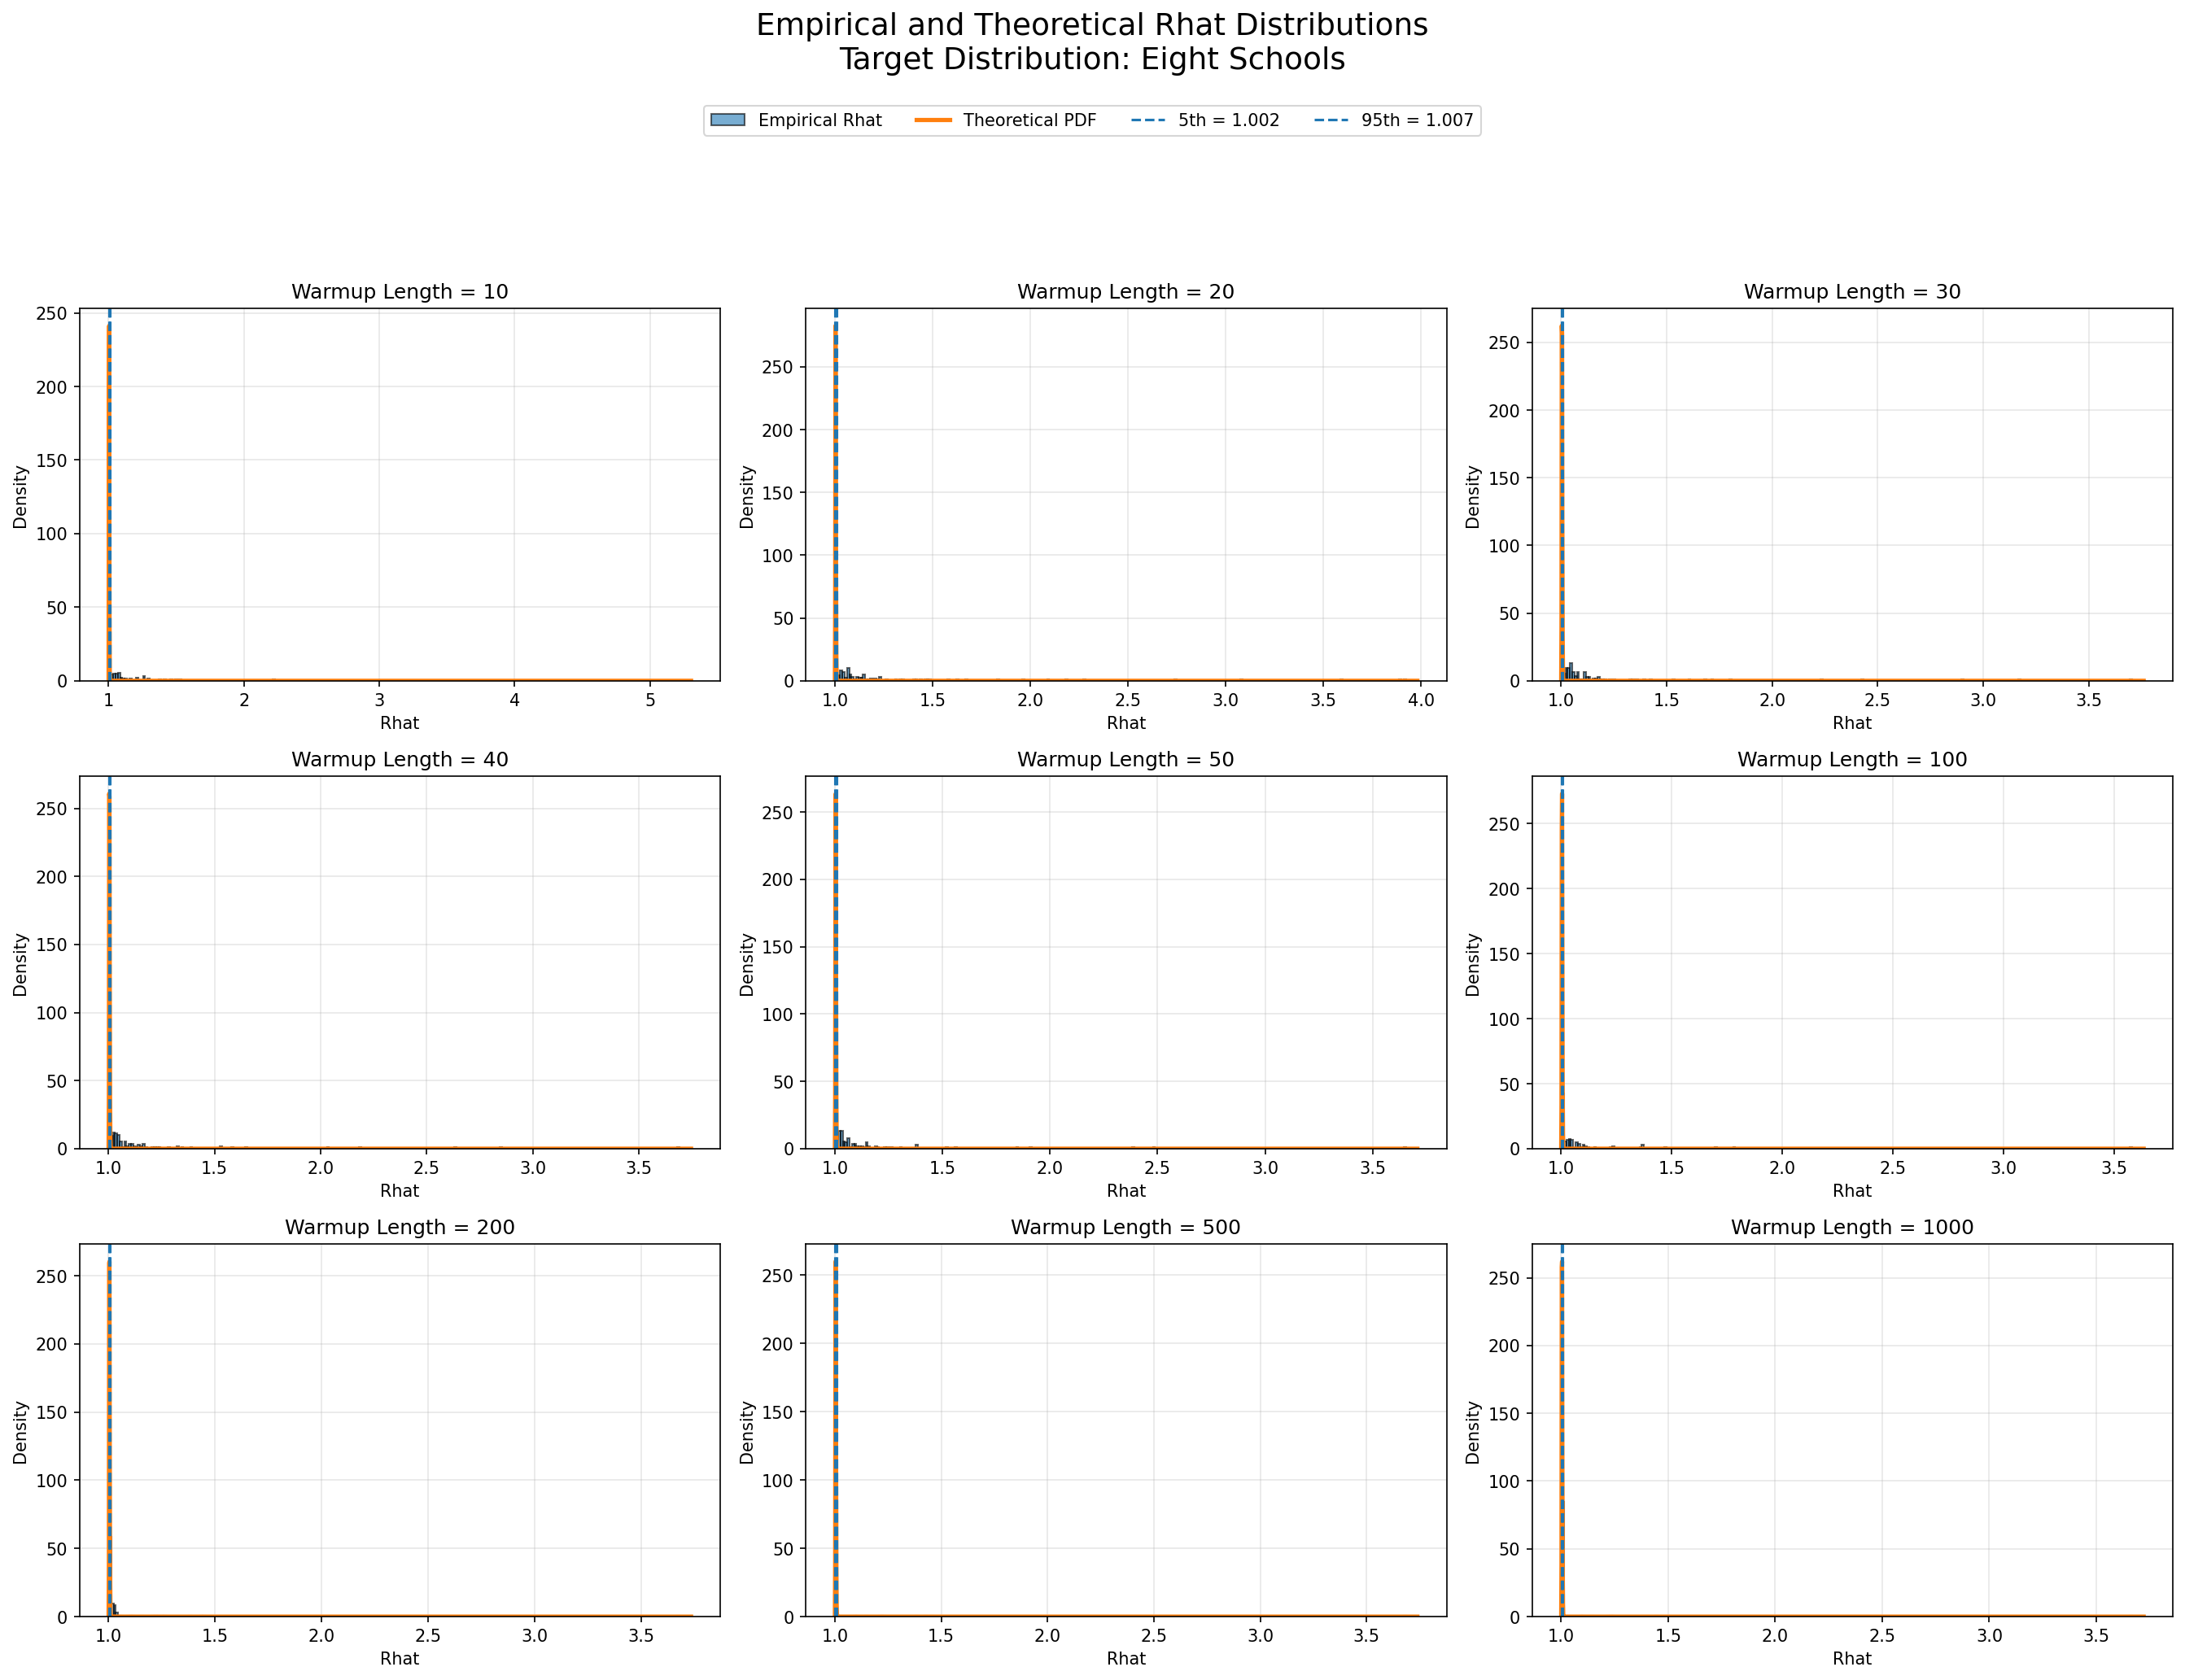

In [ ]:
plot_rhat_histograms_with_pdf(
    bjx_R_Hat_c_df,
    "Eight Schools",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins=250
)

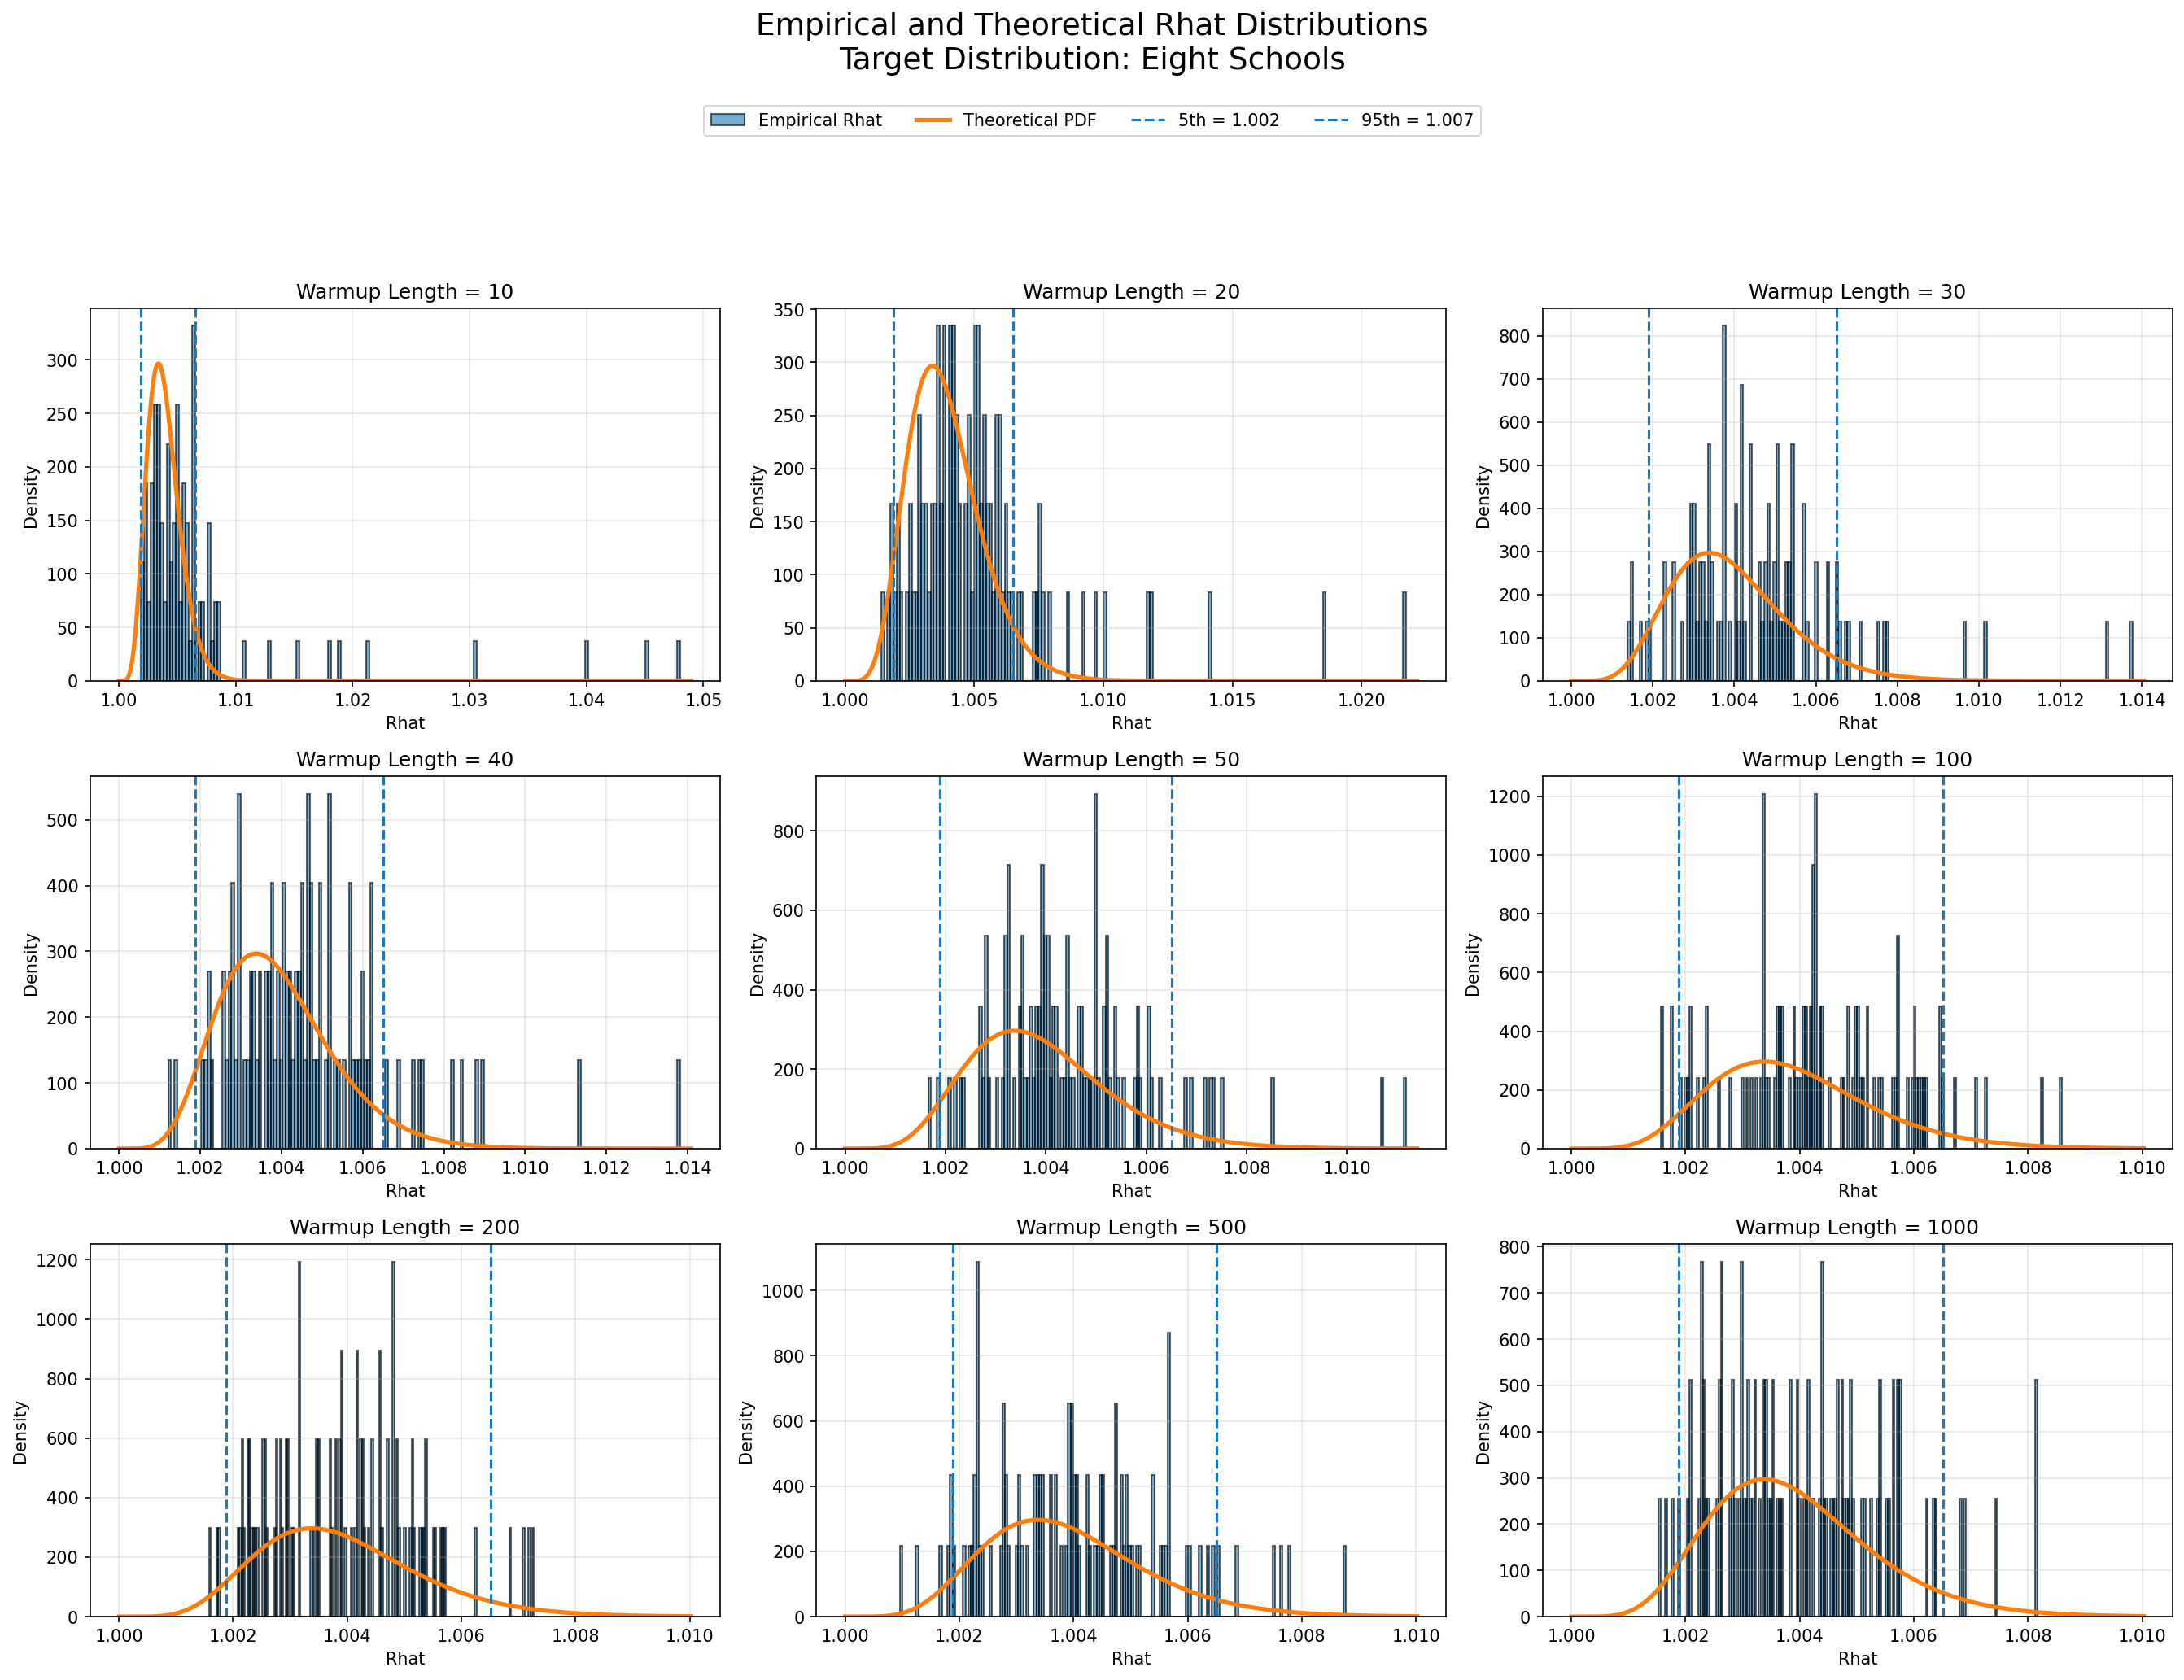

In [ ]:
plot_rhat_histograms_with_pdf(
    pf_R_Hat_c_df,
    "Eight Schools",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins=170
)

**Diagonal Experiment**

In [ ]:
# Eight School Distritbution:
# MSE vs nested Rhat:
R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Diag_1_1_Rhat_c.pkl"
R_Hat_c_df = pd.read_pickle(R_Hat_c_path)

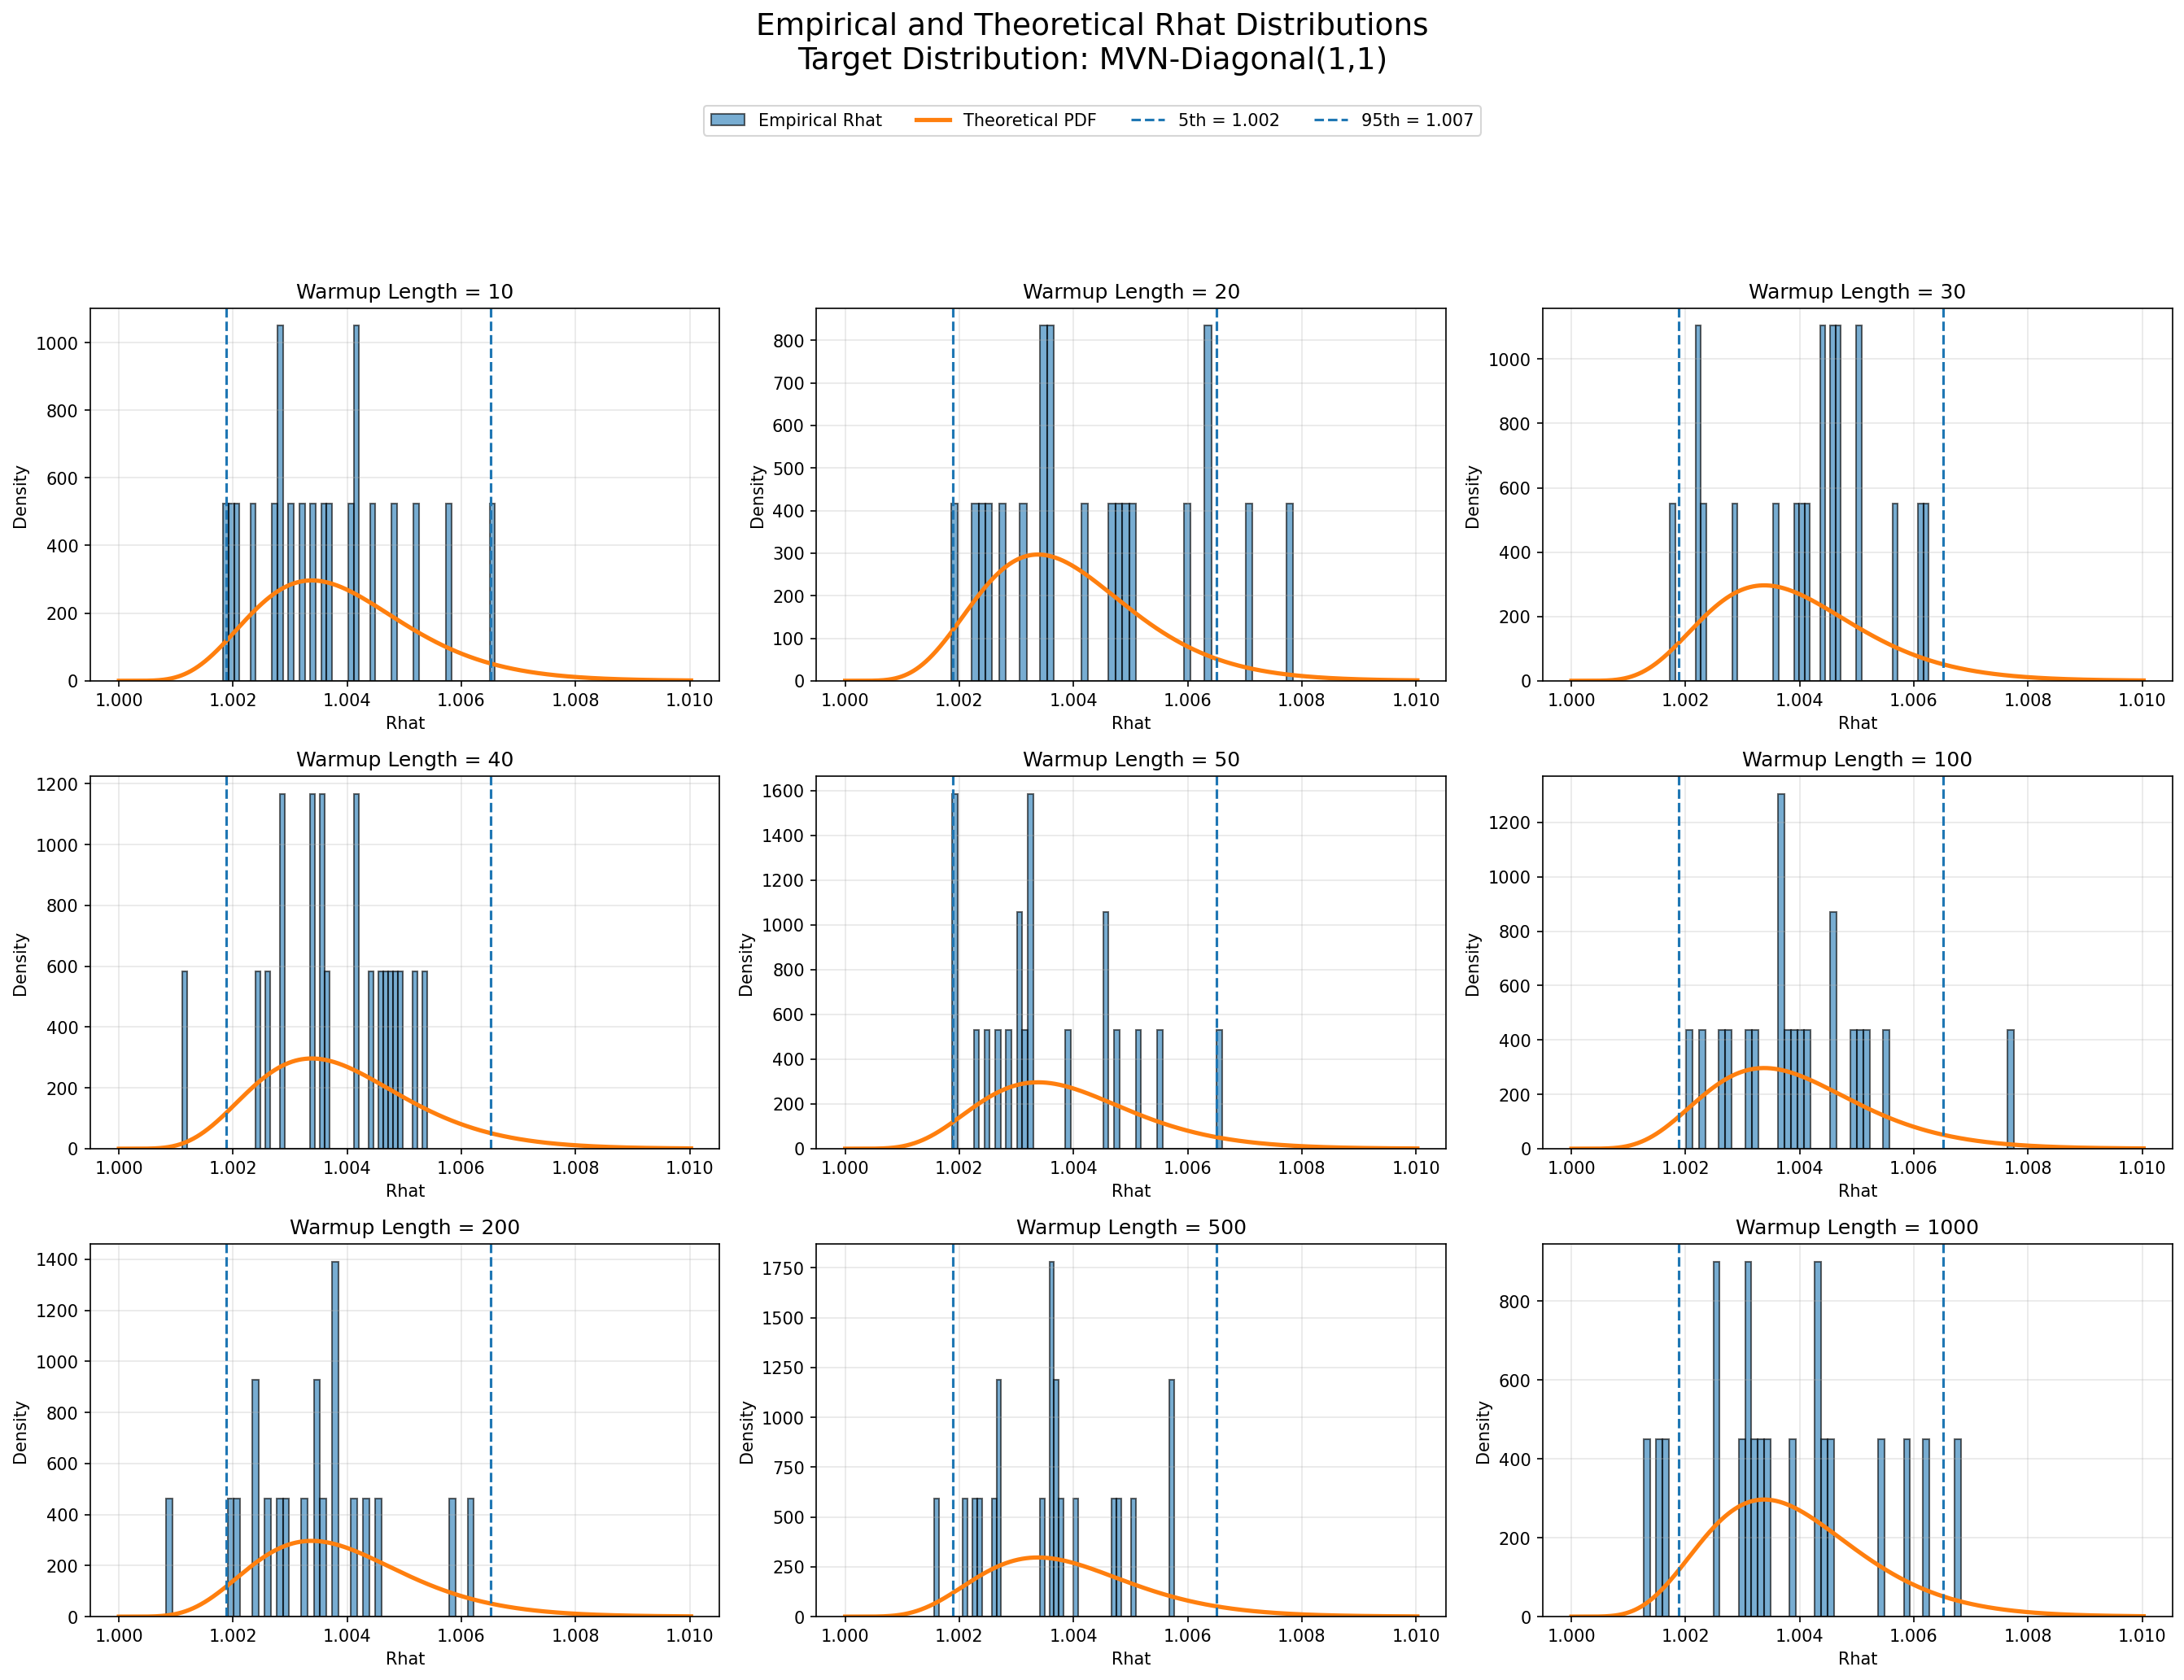

In [ ]:
plot_rhat_histograms_with_pdf(
    R_Hat_c_df,
    "MVN-Diagonal(1,1)",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins=50
)

In [ ]:
# MSE vs nested Rhat:
R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Diag_10_1_Rhat_c.pkl"
R_Hat_c_df = pd.read_pickle(R_Hat_c_path)

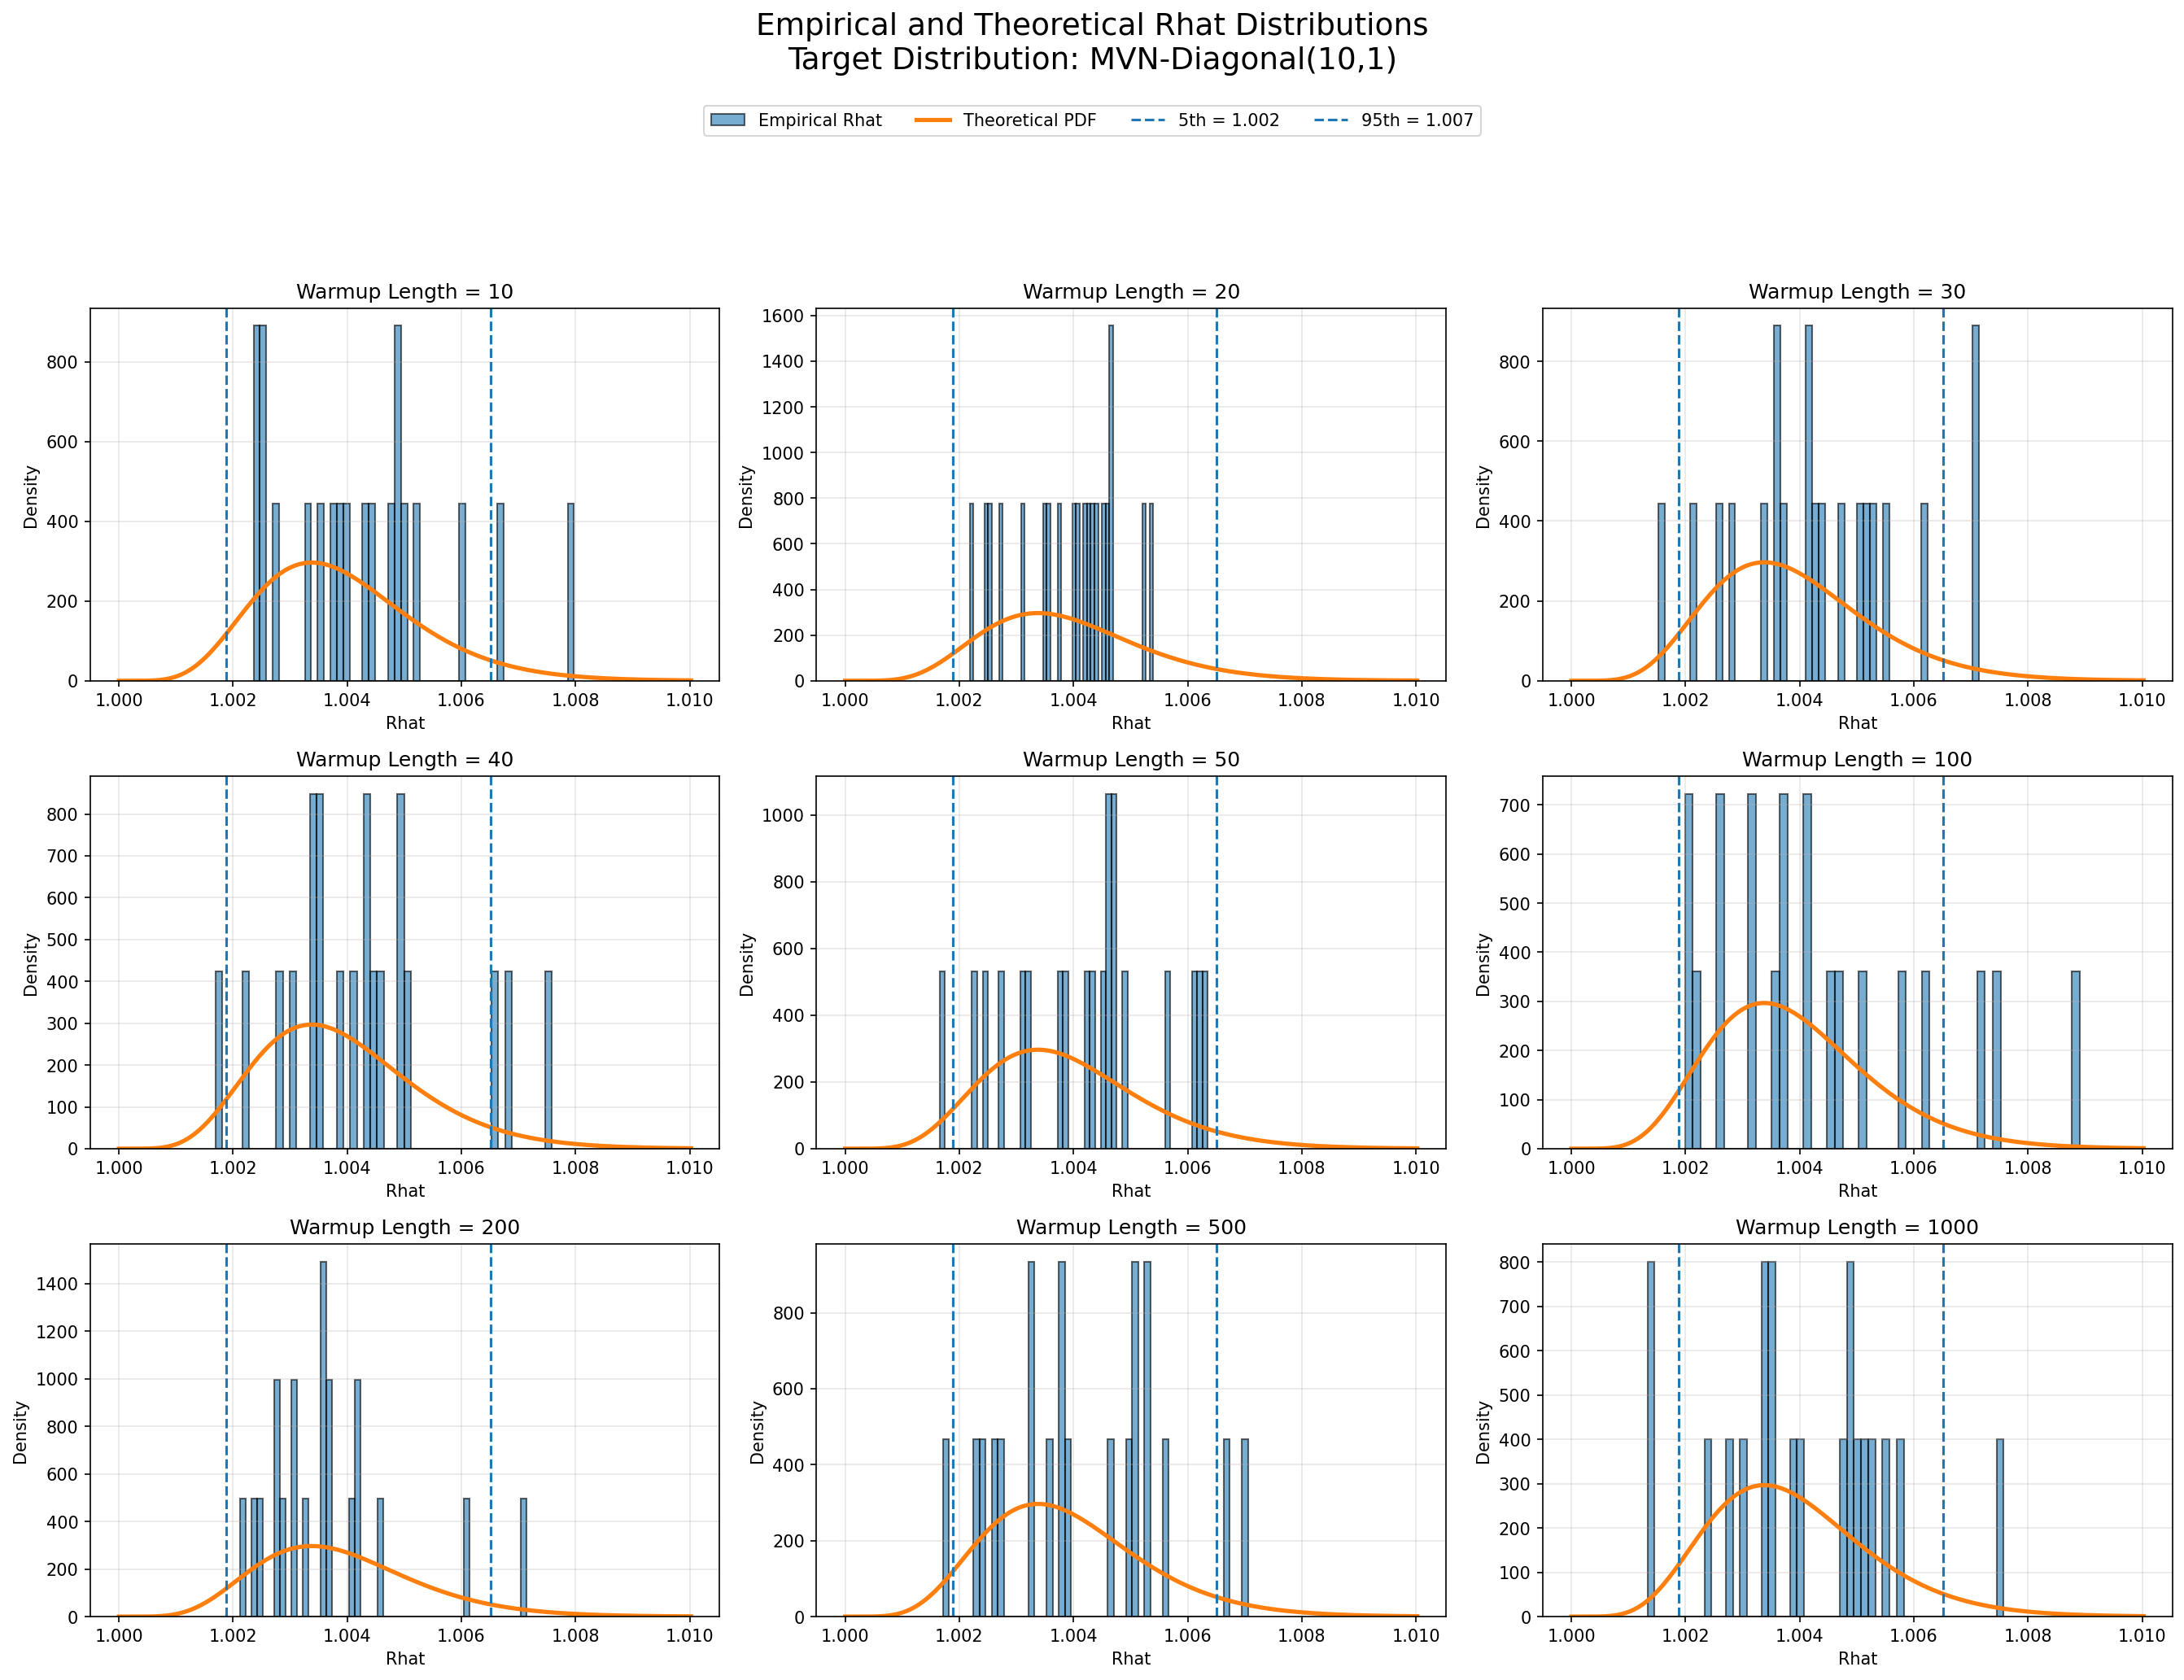

In [ ]:
plot_rhat_histograms_with_pdf(
    R_Hat_c_df,
    "MVN-Diagonal(10,1)",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins=50
)

In [ ]:
# MSE vs nested Rhat:
R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Diag_100_1_Rhat_c.pkl"
R_Hat_c_df = pd.read_pickle(R_Hat_c_path)

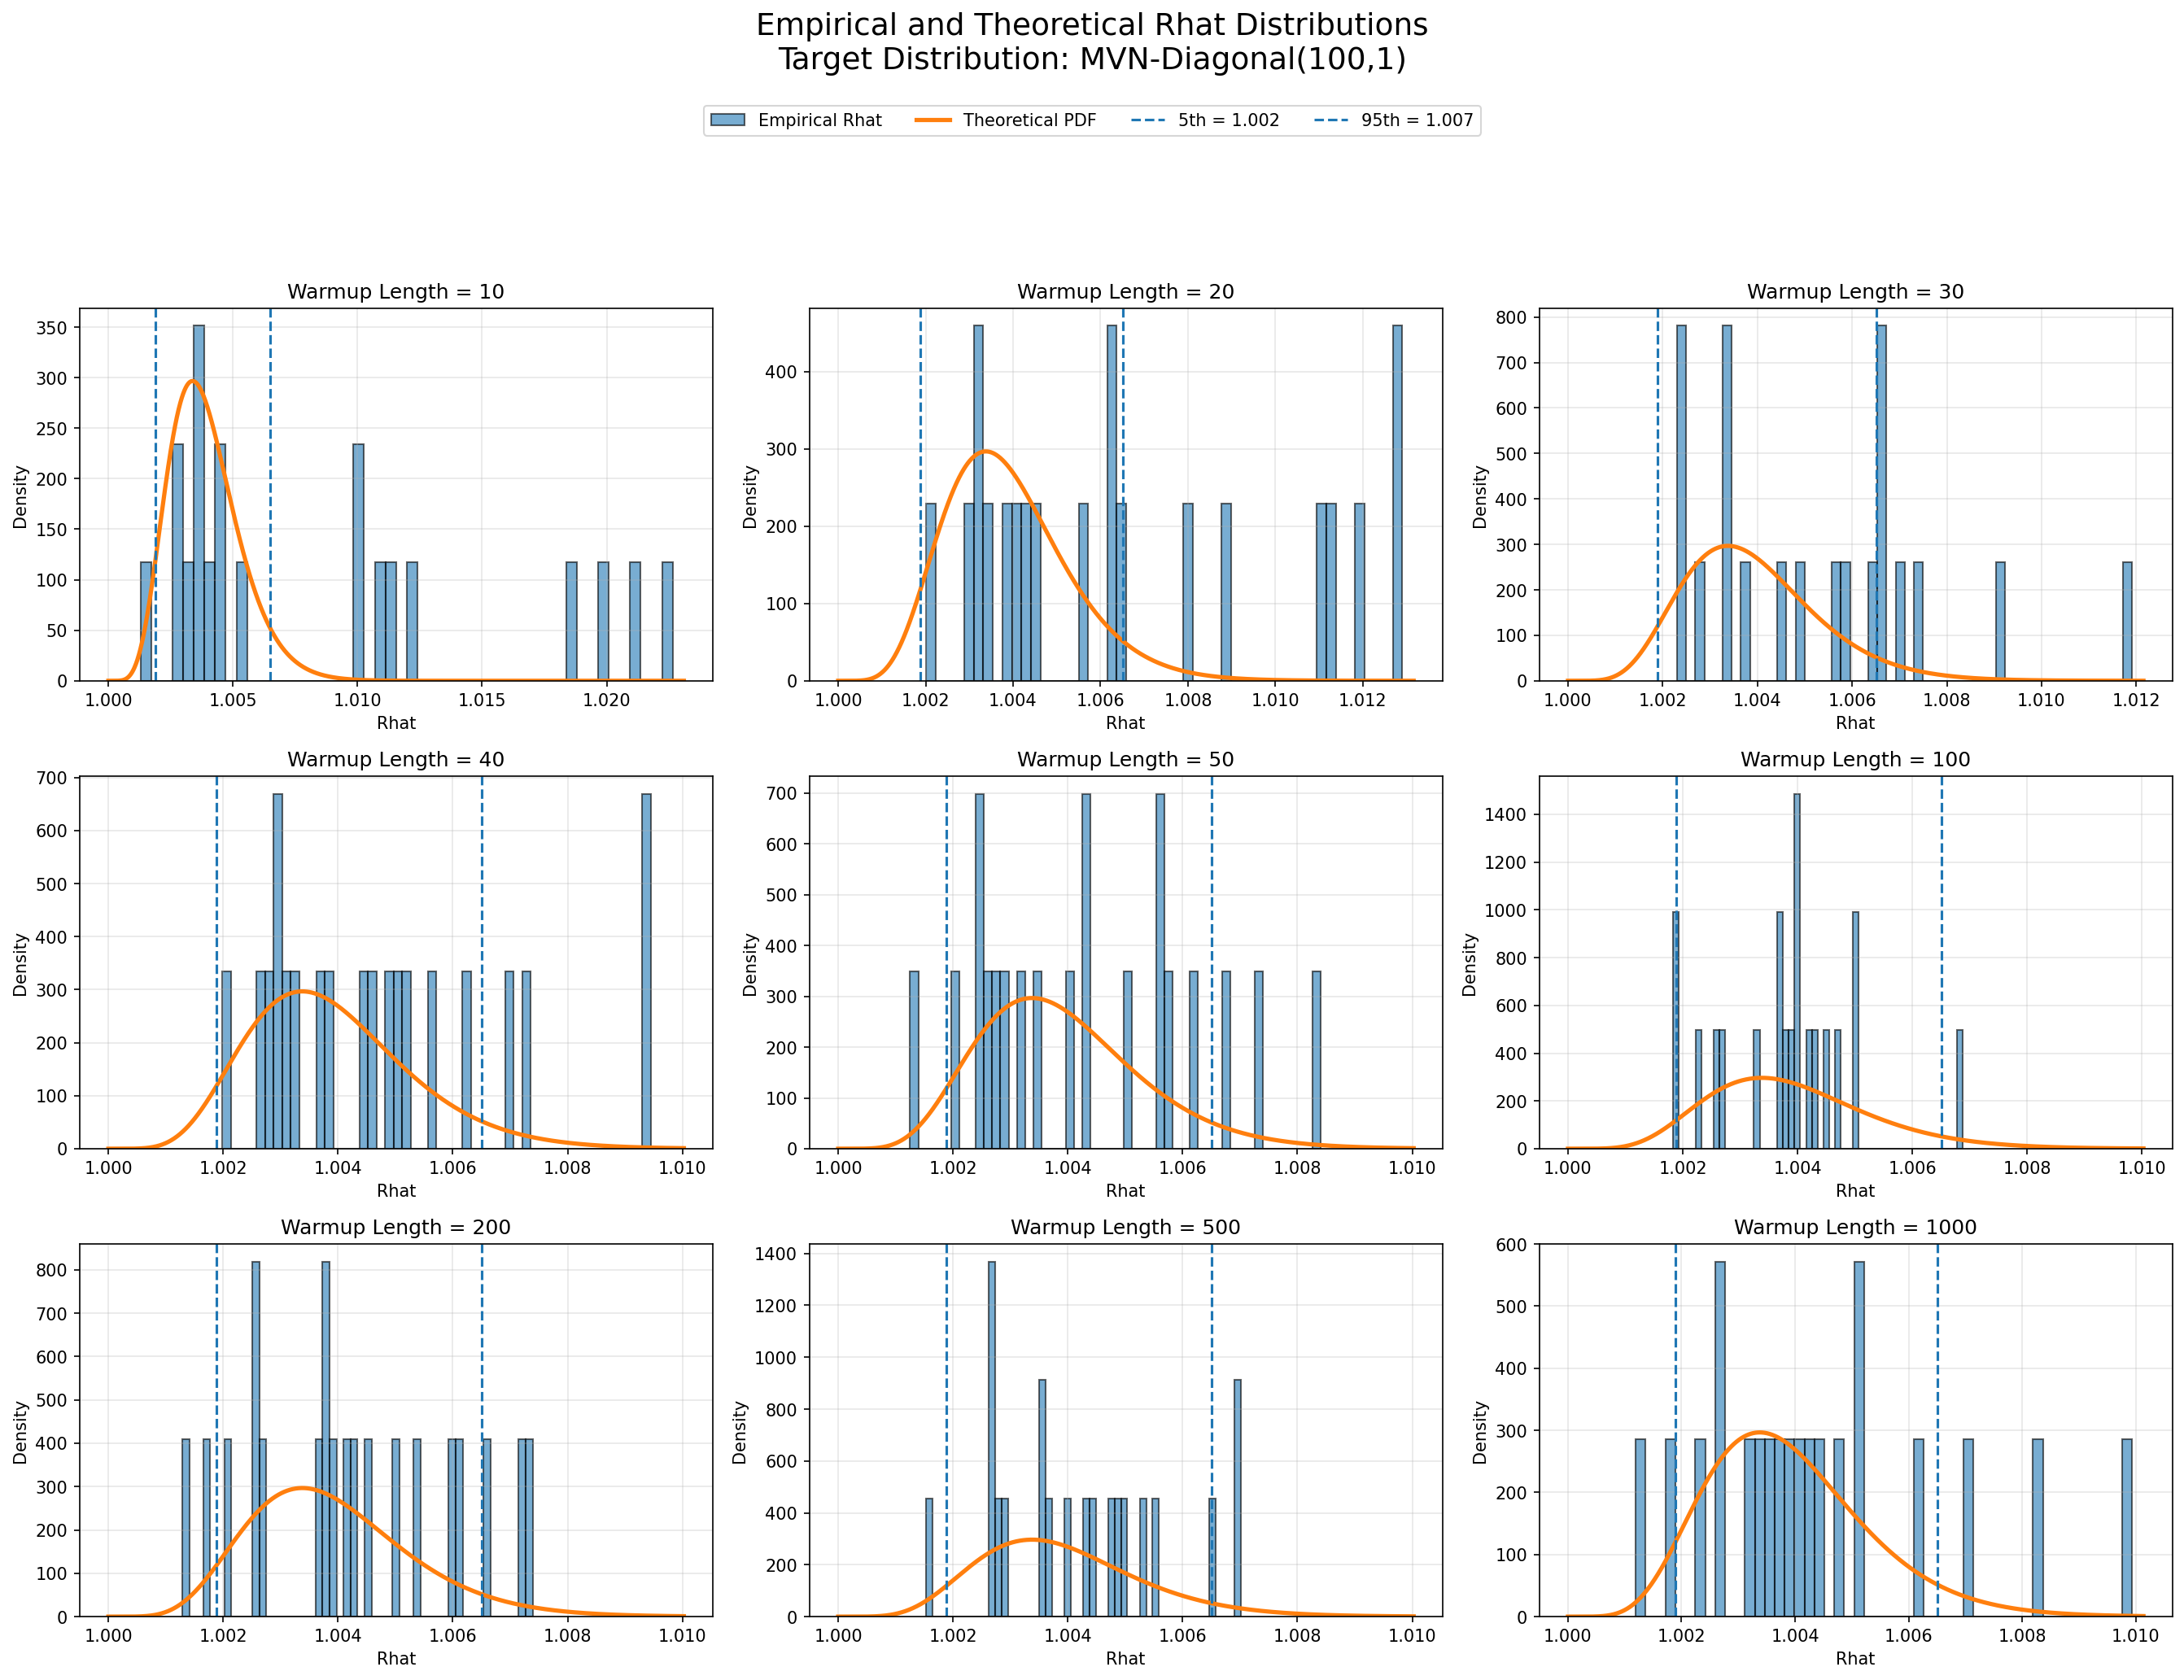

In [ ]:
plot_rhat_histograms_with_pdf(
    R_Hat_c_df,
    "MVN-Diagonal(100,1)",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins=50
)

In [ ]:
# MSE vs nested Rhat:
R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Diag_1000_1_Rhat_c.pkl"
R_Hat_c_df = pd.read_pickle(R_Hat_c_path)

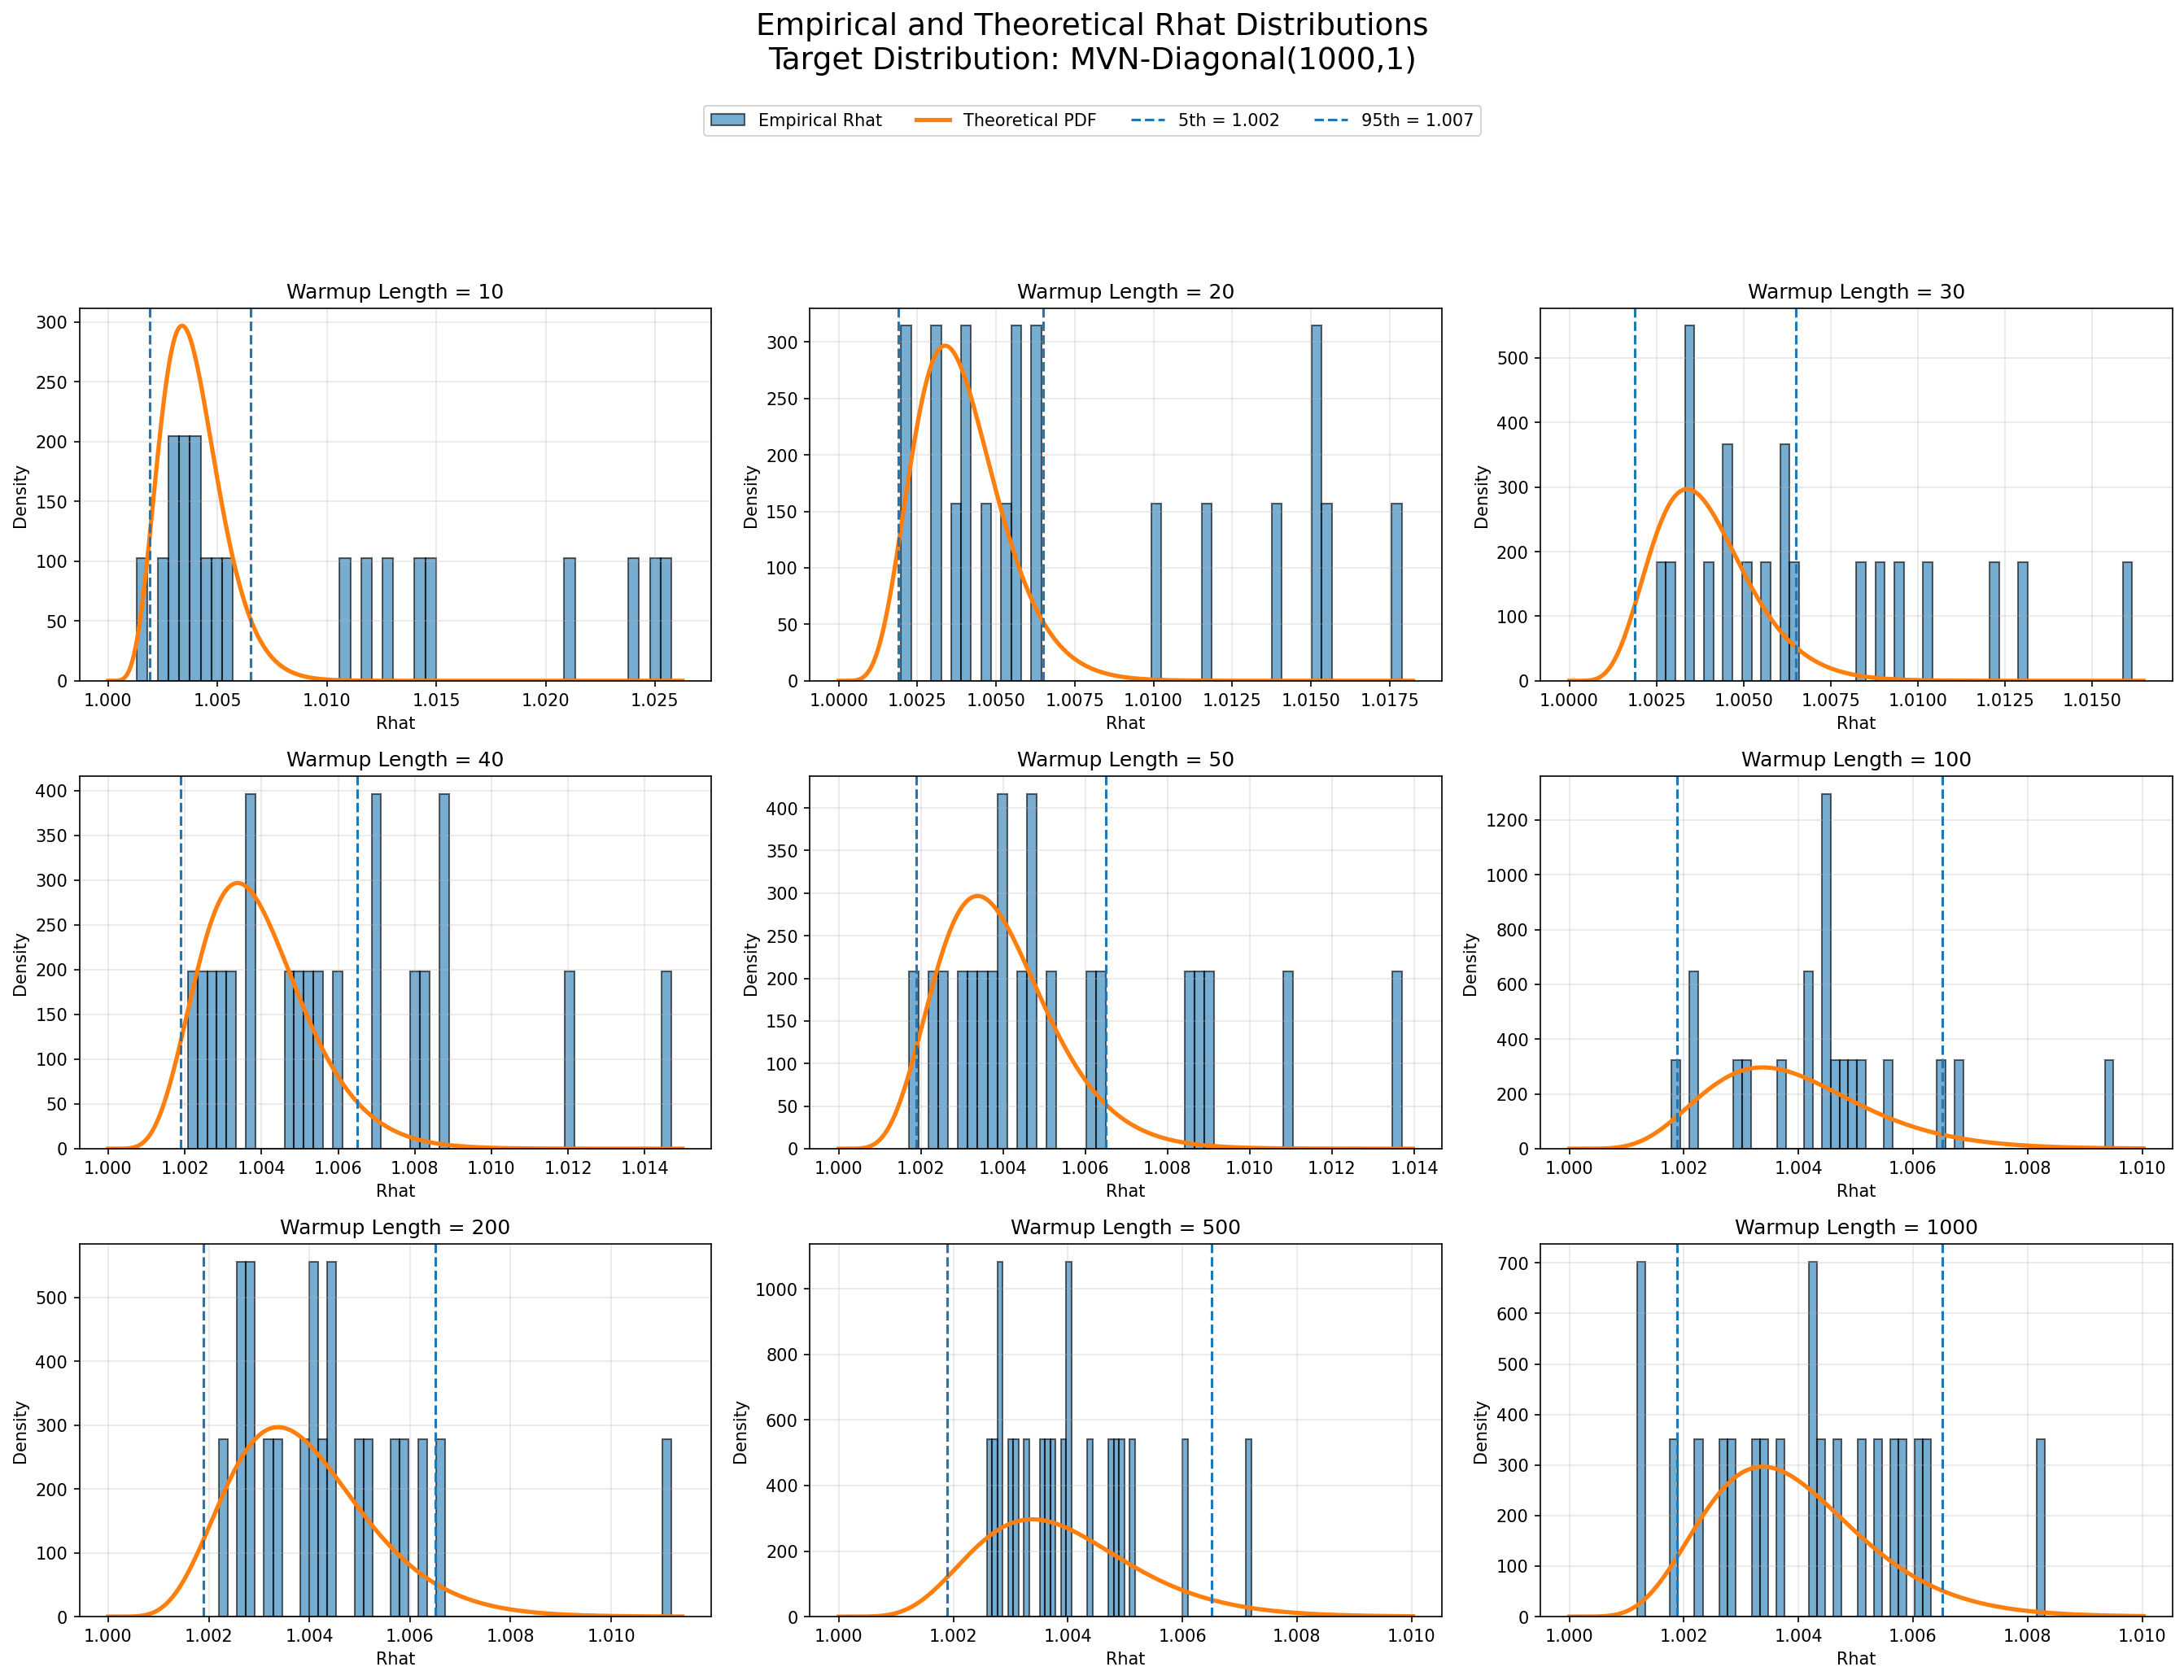

In [ ]:
plot_rhat_histograms_with_pdf(
    R_Hat_c_df,
    "MVN-Diagonal(1000,1)",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins=50
)